## Lilit Poghosyan, Time Series Forecast, Individual Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import GridSearchCV

# statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.vector_ar.var_model import VAR

# tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Conv1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

### Preprocessing

In [19]:
# LOAD DATA
df = pd.read_csv("weatherHistory.csv")

# Convert date
df["Formatted Date"] = pd.to_datetime(
    df["Formatted Date"],
    utc=True
)

In [20]:
#Sort and remove duplicate timestamps
df = df.sort_values("Formatted Date")
df = df.drop_duplicates(
    subset="Formatted Date",
    keep="first"
)

In [21]:
#Set index
df.set_index("Formatted Date", inplace=True)

#Set hourly frequency
df = df.asfreq("h")

In [22]:
# Select columns
cols = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
    "Pressure (millibars)"
]

In [23]:
df = df[cols]
#df.head
df.isnull().sum()

# Fill missing values
df = df.ffill()

### STL decomposition

The STL decomposition separates the temperature series into trend, seasonal, and residual components for one year (2006). 

- The trend shows the long-term yearly temperature pattern, with temperatures increasing toward summer and decreasing afterward. 
- The seasonal component captures the repeating daily temperature cycles, while 
- The residuals represent random fluctuations remaining after removing trend and seasonality.

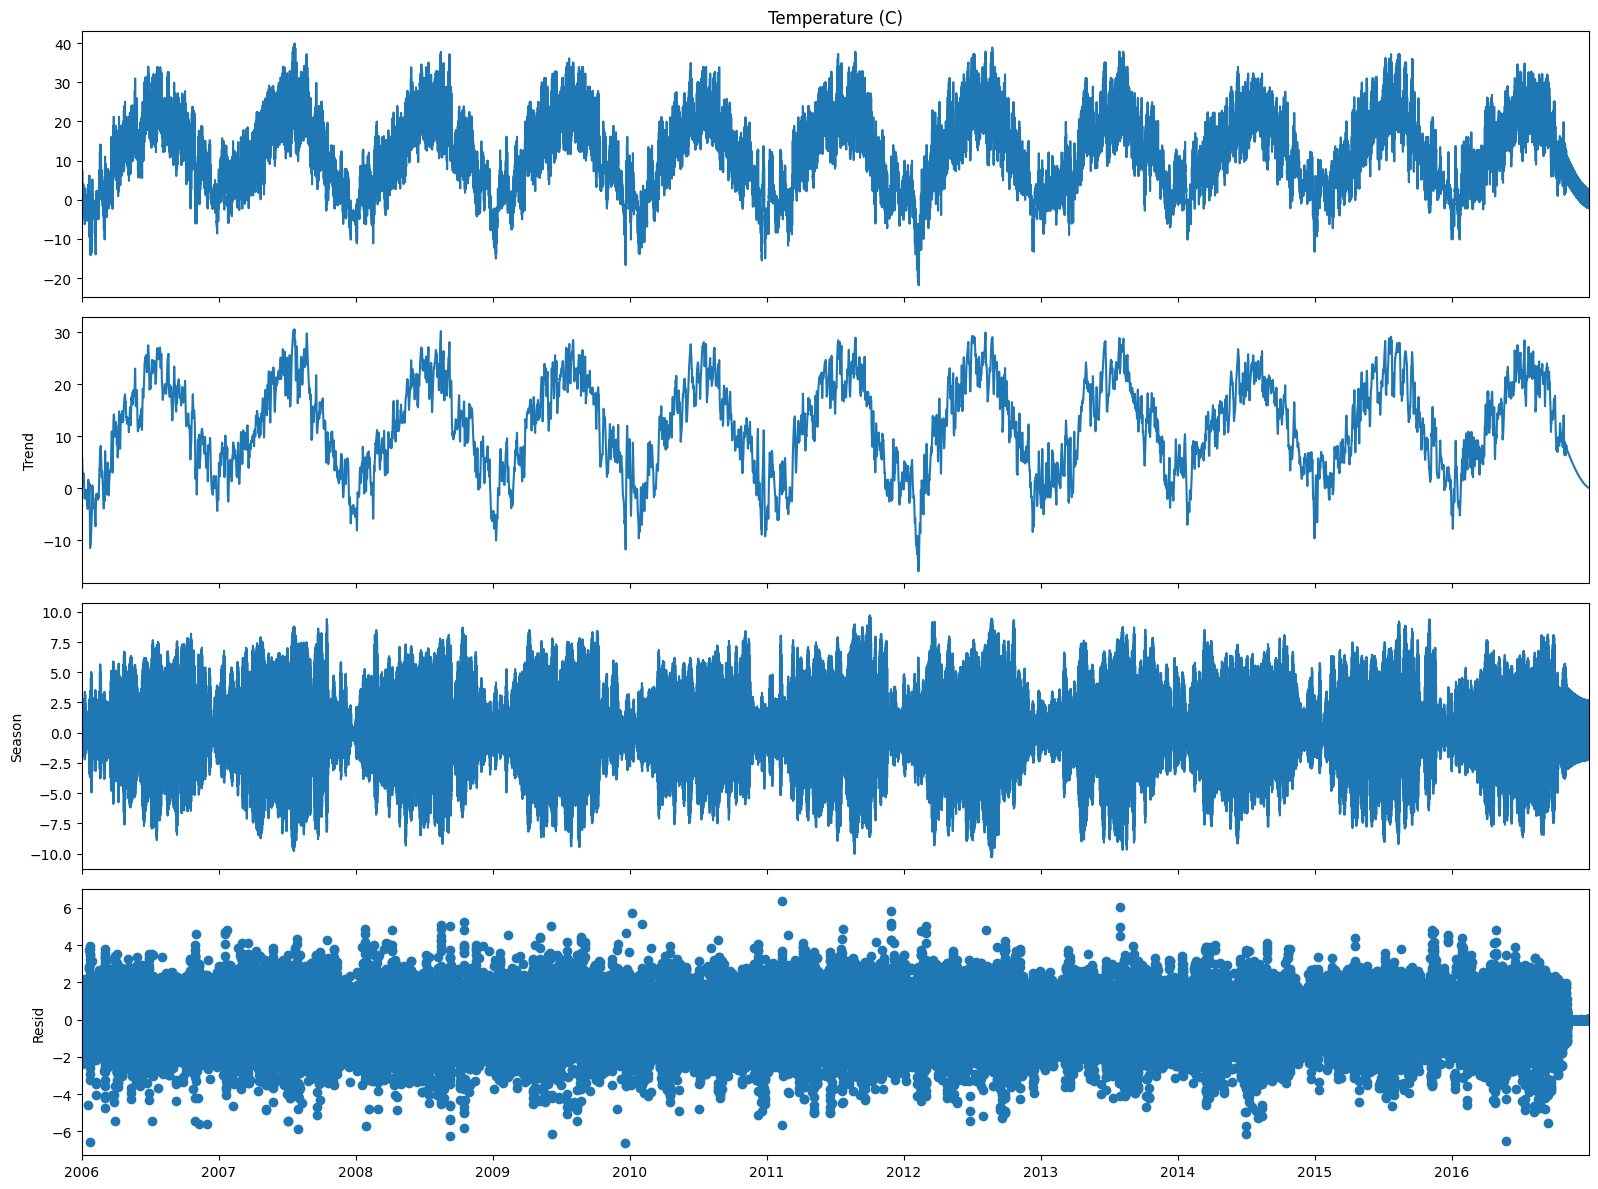

In [8]:
full_series = df["Temperature (C)"]

# STL decomposition
stl = STL(
    full_series,
    period=24
)

result = stl.fit()

# Plot
fig = result.plot()
fig.set_size_inches(16, 12)

plt.tight_layout()
plt.show()

The STL decomposition separates the full data (the temperature) series into trend, seasonal, and residual components. The trend shows the long-term temperature pattern, with temperatures increasing and decreasing cyclically over the years. 

- The seasonal component captures the repeating daily temperature variations caused by day–night cycles. 
- The residuals represent random fluctuations remaining after removing trend and seasonality and are mostly centered around zero. 
- Overall, the graph indicates that the temperature data contains strong seasonal and trend patterns, and STL decomposition effectively captures these structures.

### Data view

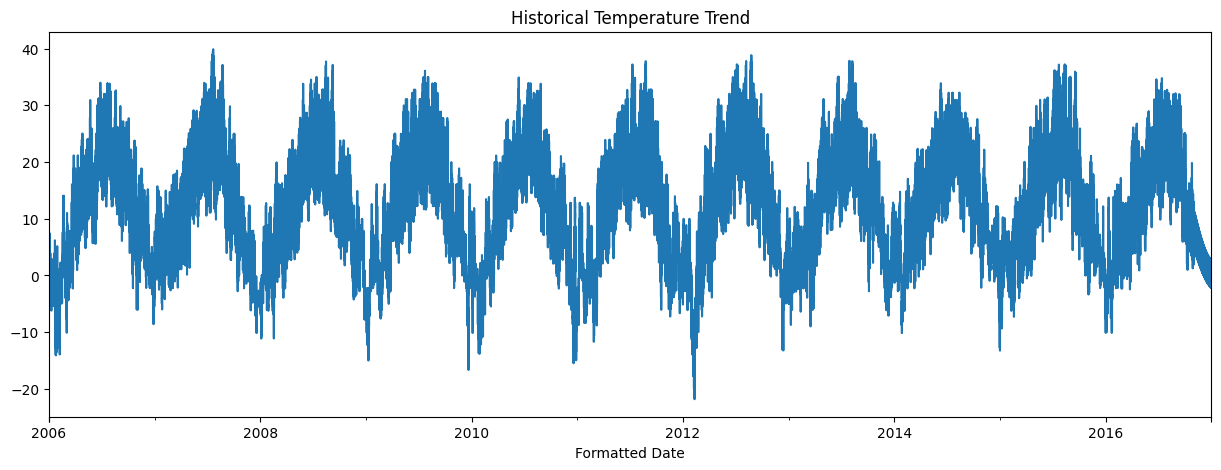

In [9]:
plt.figure(figsize=(15,5))
df["Temperature (C)"].plot()
plt.title("Historical Temperature Trend")
plt.show()

The historical temperature series exhibits strong recurring annual seasonality with stable fluctuations over time. No pronounced long-term trend is visible.

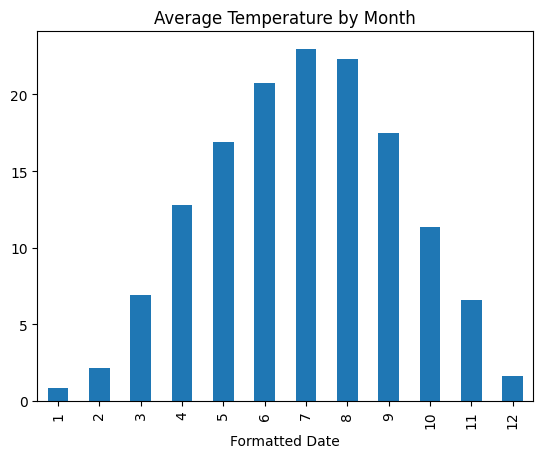

In [9]:
df.groupby(df.index.month)["Temperature (C)"].mean().plot(kind="bar")
plt.title("Average Temperature by Month")
plt.show()

Monthly averages confirm a strong yearly seasonal cycle, with peak temperatures in summer (July–August) and minimum temperatures in winter (January–February).

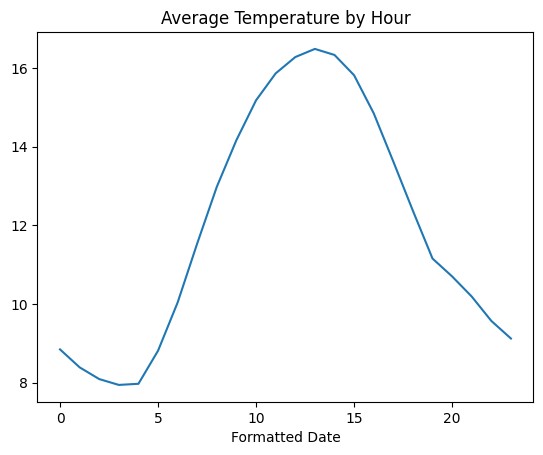

In [10]:
df.groupby(df.index.hour)["Temperature (C)"].mean().plot()
plt.title("Average Temperature by Hour")
plt.show()

The graph shows a clear daily temperature cycle. Temperatures are lowest during the early morning hours, increase throughout the day, peak in the early afternoon, and then gradually decrease during the evening and night.

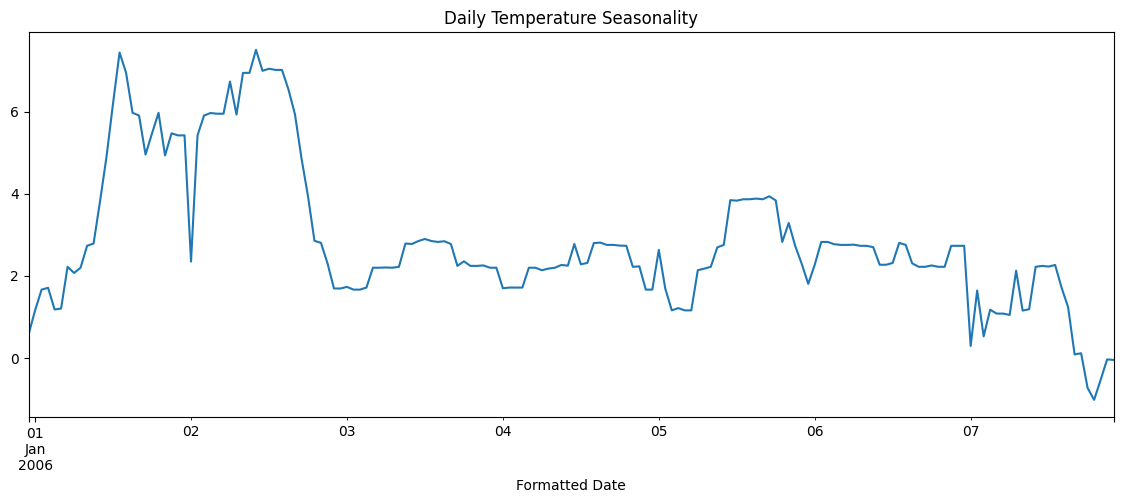

In [11]:
# 7 days
df["Temperature (C)"].iloc[:24*7].plot(figsize=(14,5))
plt.title("Daily Temperature Seasonality")
plt.show()

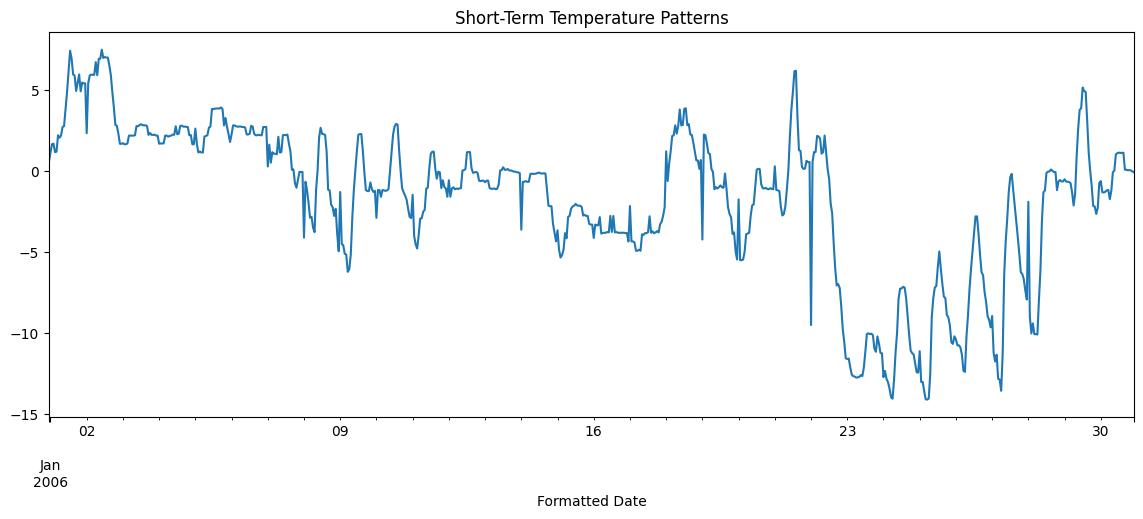

In [12]:
# 30 days
df["Temperature (C)"].iloc[:24*30].plot(figsize=(14,5))
plt.title("Short-Term Temperature Patterns")
plt.show()

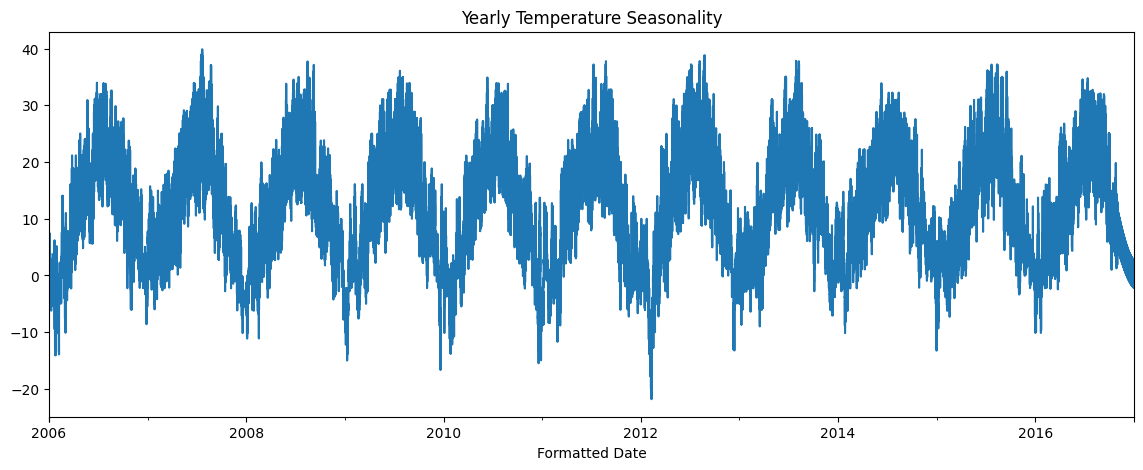

In [13]:
# Full dataset
df["Temperature (C)"].plot(figsize=(14,5))
plt.title("Yearly Temperature Seasonality")
plt.show()

By inspecting all the graphs, the dataset appears to contain multiple seasonal patterns, not only yearly seasonality.

The strongest and most visible pattern is the yearly seasonality, shown by the repeating annual temperature cycles in the full historical trend plot and supported by the average monthly temperature graph, where temperatures consistently peak during summer months and decrease during winter months.

In addition, the average temperature by hour graph indicates the presence of daily seasonality. Temperatures tend to rise during daytime hours and decrease during nighttime hours, showing a repeating 24-hour cycle typical for hourly weather data.

The short-term plots also suggest local cyclical fluctuations and short-term temporal dependencies, although these patterns are less regular and weaker compared to the yearly and daily seasonal structures.

Therefore, the dataset can be considered a multi-seasonal time series containing:

* strong yearly seasonality,
* noticeable daily seasonality,
* and smaller short-term fluctuations/noise.


### Evaluation metrics function 

In [30]:
results = []

def evaluate(name, y_true, y_pred):

    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Remove NaN values if they exist
    mask = ~(
        np.isnan(y_true) | np.isnan(y_pred)
    )

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # Metrics
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    denominator = (
        np.abs(y_true) + np.abs(y_pred)
    ) / 2

    # Avoid division by zero
    denominator = np.where(
        denominator == 0,
        1e-8,
        denominator
    )

    smape = np.mean(
        np.abs(y_true - y_pred) / denominator
    ) * 100

    # R²
    r2 = r2_score(
        y_true,
        y_pred
    )

    # Store results
    results.append([
        name,
        rmse,
        mae,
        smape,
        r2
    ])

    # Print results
    print(f"\n{name}")

    print("RMSE :", round(rmse, 3))
    print("MAE  :", round(mae, 3))
    print("sMAPE:", round(smape, 3))
    print("R2   :", round(r2, 3))

### Stationarity Check 

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name="Series"):
    
    result = adfuller(series.dropna())

    adf_stat = result[0]
    p_value = result[1]
    used_lags = result[2]
    n_obs = result[3]
    critical_values = result[4]

    print(f"Augmented Dickey-Fuller Test : {name}")

    print(f"ADF Statistic       : {adf_stat:.6f}")
    print(f"P-value             : {p_value:.10f}")
    print(f"Used Lags           : {used_lags}")
    print(f"Number of Observations : {n_obs}")
    print("\nCritical Values:")

    for key, value in critical_values.items():
        print(f"   {key:>4} : {value:.6f}")

    print("\nConclusion:")

    if p_value < 0.05:
        print("✅ Reject Null Hypothesis")
        print("✅ Series is STATIONARY")
        print("✅ Differencing may NOT be required")
    else:
        print("❌ Fail to Reject Null Hypothesis")
        print("❌ Series is NON-STATIONARY")    
        print("❌ Differencing may be required")

# Run test
adf_test(df["Temperature (C)"], "Temperature (C)")

Augmented Dickey-Fuller Test : Temperature (C)
ADF Statistic       : -7.399214
P-value             : 0.0000000001
Used Lags           : 67
Number of Observations : 96364

Critical Values:
     1% : -3.430418
     5% : -2.861570
    10% : -2.566786

Conclusion:
✅ Reject Null Hypothesis
✅ Series is STATIONARY
✅ Differencing may NOT be required


Raw temperature series is statistically stationary enough for ACF/PACF interpretation.

### ACF, PACF 

<Figure size 1200x500 with 0 Axes>

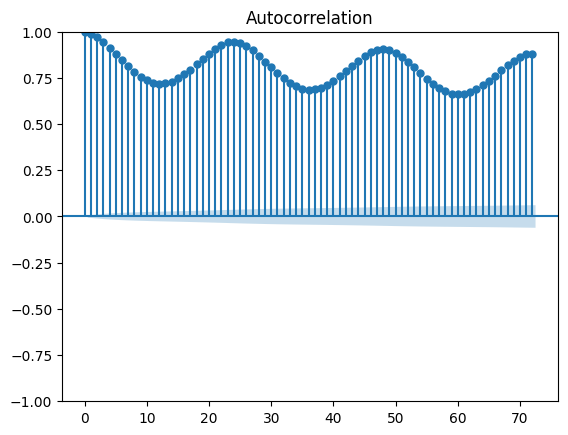

<Figure size 1200x500 with 0 Axes>

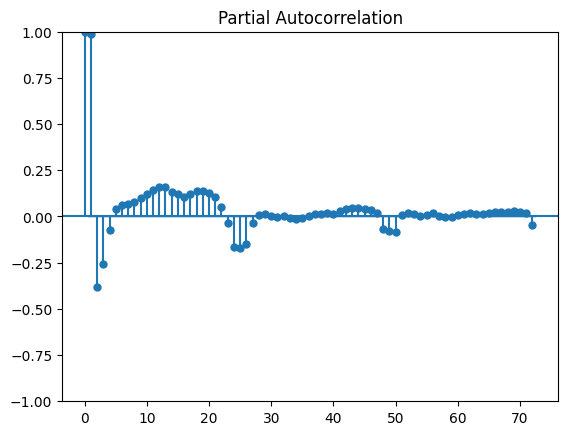

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series = df["Temperature (C)"]

plt.figure(figsize=(12,5))
plot_acf(series, lags=72)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(series, lags=72, method="ywm")
plt.show()

### Meaning for ACF 

The ACF plot shows strong positive autocorrelation across many lags, meaning that temperature values are highly related to previous observations. 

- The repeating wave-like pattern indicates the presence of seasonality in the data, particularly a daily cycle caused by hourly temperature changes. 
- Since many autocorrelation values remain high and significant, the series demonstrates strong temporal dependence and is likely non-stationary.


### Meaning  for PACF 

- Direct dependence from recent past lags
- Strongest impact from lag 1 / 2 / maybe 3. 
- This is more consistent with AR behavior.

### Seasonal Differencing

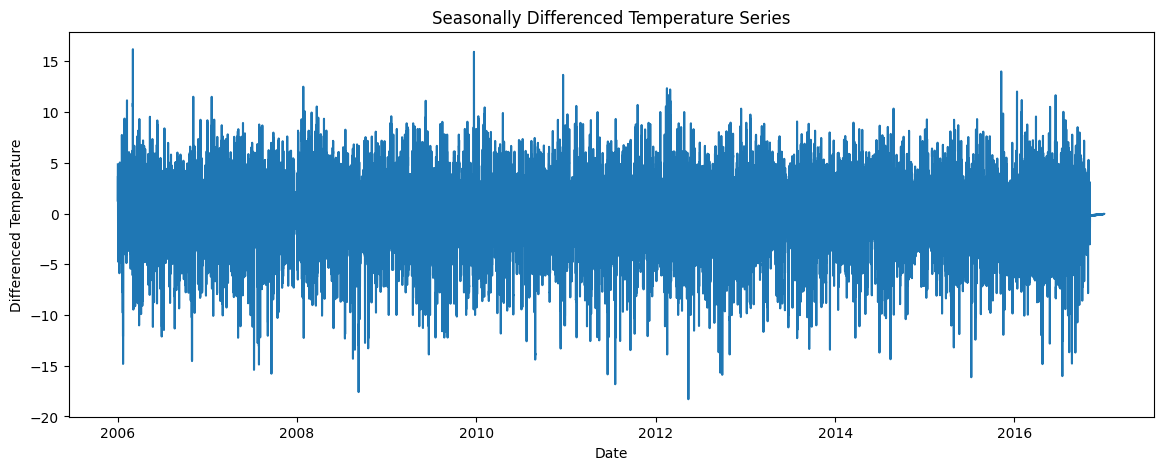

In [16]:
seasonal_diff = series.diff(24)

# Remove missing values
seasonal_diff = seasonal_diff.dropna()

# Plot seasonally differenced series
plt.figure(figsize=(14, 5))

plt.plot(seasonal_diff)

plt.title("Seasonally Differenced Temperature Series")
plt.xlabel("Date")
plt.ylabel("Differenced Temperature")

plt.show()

Since the data is clearly seasonal is it reasonable to do seasonal differencing 

In [49]:
# ADF Test
adf_result = adfuller(seasonal_diff)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -43.774506903579805
p-value: 0.0


After seasonal differening adf score is less than 0.05 indicating that the seasonal differenced data is stationary 

### ACF and PACF plots
  

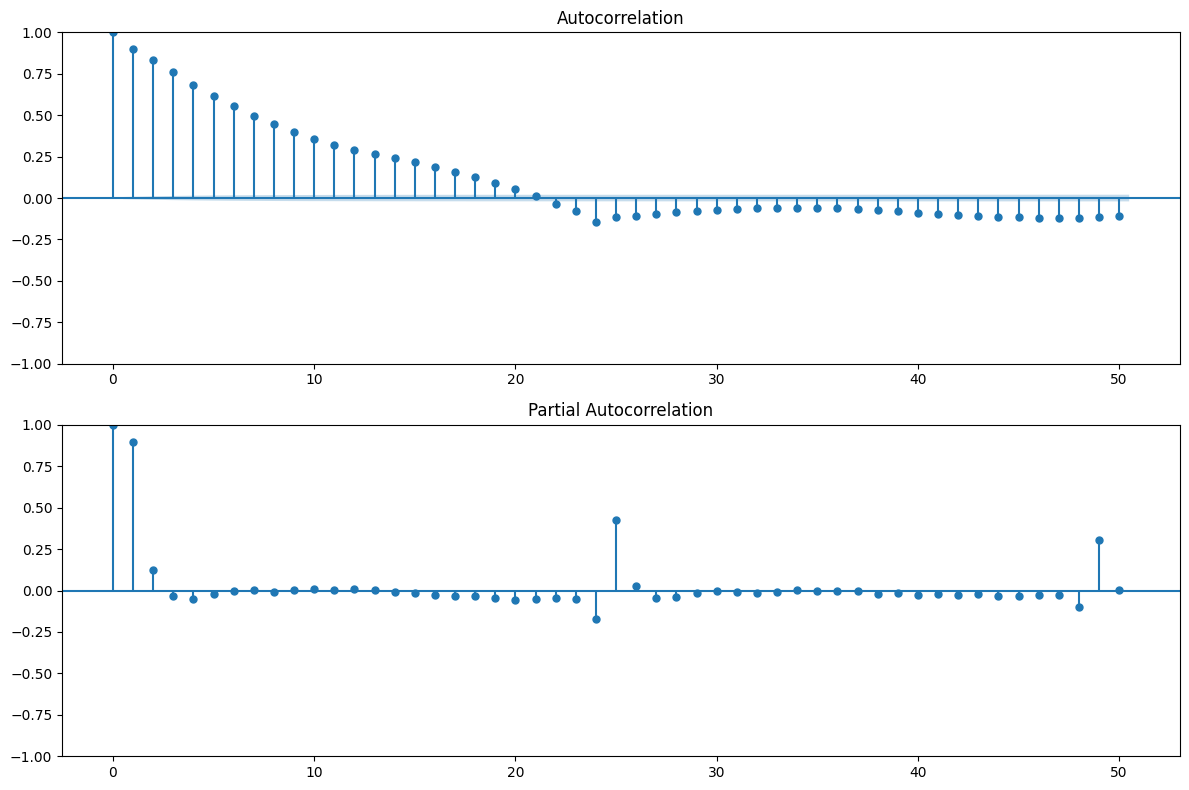

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(seasonal_diff, lags=50, ax=ax[0])
plot_pacf(seasonal_diff, lags=50, ax=ax[1])

plt.tight_layout()
plt.show()

### Interpretation of ACF and PACF after seasonal differencing 

After seasonal differencing, the strong daily seasonal pattern was mostly removed from the temperature series. 
- The ACF plot shows that autocorrelation gradually decreases instead of repeating in a wave-like pattern, indicating improved stationarity. 
- The PACF plot shows a strong spike at lag 1, suggesting that recent observations still strongly influence current values. 
- Overall, the series becomes more suitable for time series forecasting after seasonal differencing.

### Feature engineering

In [25]:
# FEATURE ENGINEERING
df["Lag_1"] = df["Temperature (C)"].shift(1)
df["Lag_24"] = df["Temperature (C)"].shift(24)
df["Rolling_24"] = df["Temperature (C)"].rolling(24).mean()

df["Hour"] = df.index.hour
df["Month"] = df.index.month
df["DayOfWeek"] = df.index.dayofweek

df.dropna(inplace=True)

### Train-test split

In [26]:
split = int(len(df) * 0.8)

# Split data chronologically
train = df.iloc[:split]
test = df.iloc[split:]

# Features and target
X_train = train.drop("Temperature (C)", axis=1)
X_test = test.drop("Temperature (C)", axis=1)

y_train = train["Temperature (C)"]
y_test = test["Temperature (C)"]

# Shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (77126, 11)
X_test shape: (19282, 11)
y_train shape: (77126,)
y_test shape: (19282,)


## Statistical Models Evaluation 
### 1. ARIMA
### 2. SARIMA
### 3. VAR

### ARIMA forecast

Best order for ARIMA through AIC

In [26]:
best_aic = float("inf")
best_order = None

for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                model = ARIMA(y_train, order=(p,d,q)).fit()

                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p,d,q)

            except:
                pass

print("BEST ARIMA MODEL SEARCH")
print(f"Best Order : ARIMA{best_order}")
print(f"Best AIC   : {best_aic:.3f}")

c:\Users\lilpo\anaconda3\envs\Stat\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


BEST ARIMA MODEL SEARCH
Best Order : ARIMA(3, 0, 3)
Best AIC   : 242562.052


In [56]:
# Train model on full training data
model_full = ARIMA(
    y_train,
    order=(3,0,3)
).fit()

# Forecast
pred_arima_full = model_full.forecast(
    steps=len(y_test)
)

# Evaluation
evaluate(
    "ARIMA Full Data",
    y_test.values,
    pred_arima_full.values)


ARIMA Full Data
RMSE : 9.112
MAE  : 7.654
sMAPE: 73.002
R2   : -0.007


* In order to compare ARIMA and SARIMA fairly, forecasting was performed using the same subset of the dataset consisting of the last 3 years of observations.

* Due to the high computational complexity of SARIMA on the full hourly dataset, the model was trained on a reduced portion of the data. The same subset was then used for ARIMA to ensure a consistent and unbiased comparison between the two models.


In [58]:
# Last 3 years of hourly data
hours_3_years = 24 * 365 * 3

# Subset
y_train_recent = y_train.iloc[-hours_3_years:]

# Train model
model_recent = ARIMA(
    y_train_recent,
    order=(3,0,3)
).fit()

# Forecast
pred_arima_recent = model_recent.forecast(
    steps=len(y_test)
)

# Evaluation
evaluate(
    "ARIMA Last 3 Years",
    y_test.values,
    pred_arima_recent.values
)


ARIMA Last 3 Years
RMSE : 9.214
MAE  : 7.767
sMAPE: 73.618
R2   : -0.03


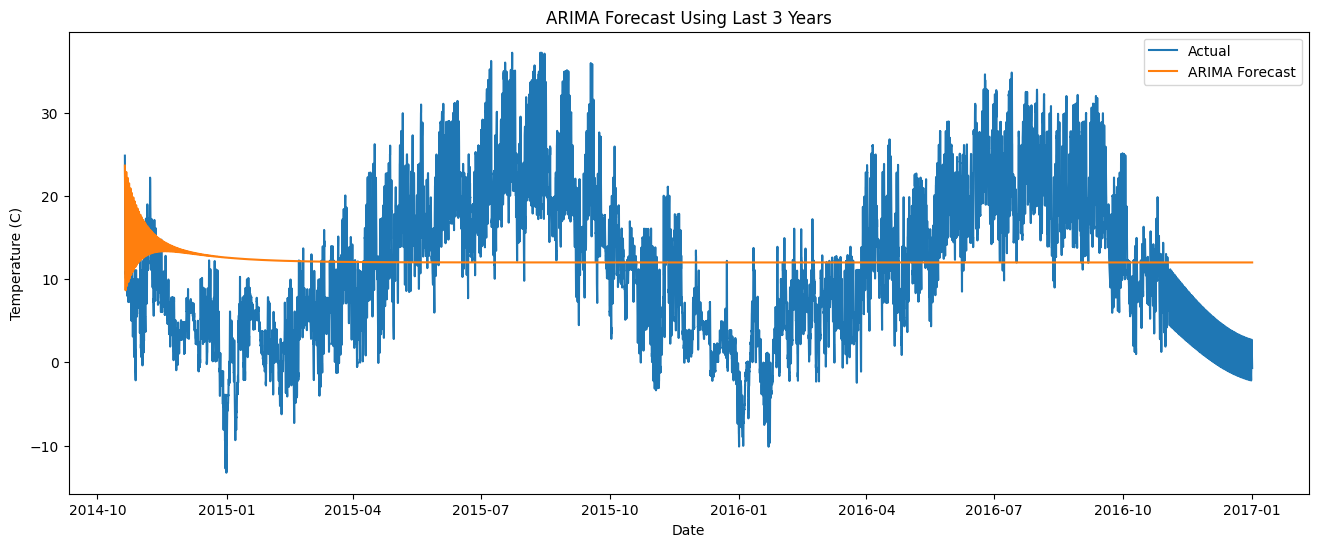

In [59]:
plt.figure(figsize=(16,6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    pred_arima_recent.values,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast Using Last 3 Years")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.legend()

plt.show()

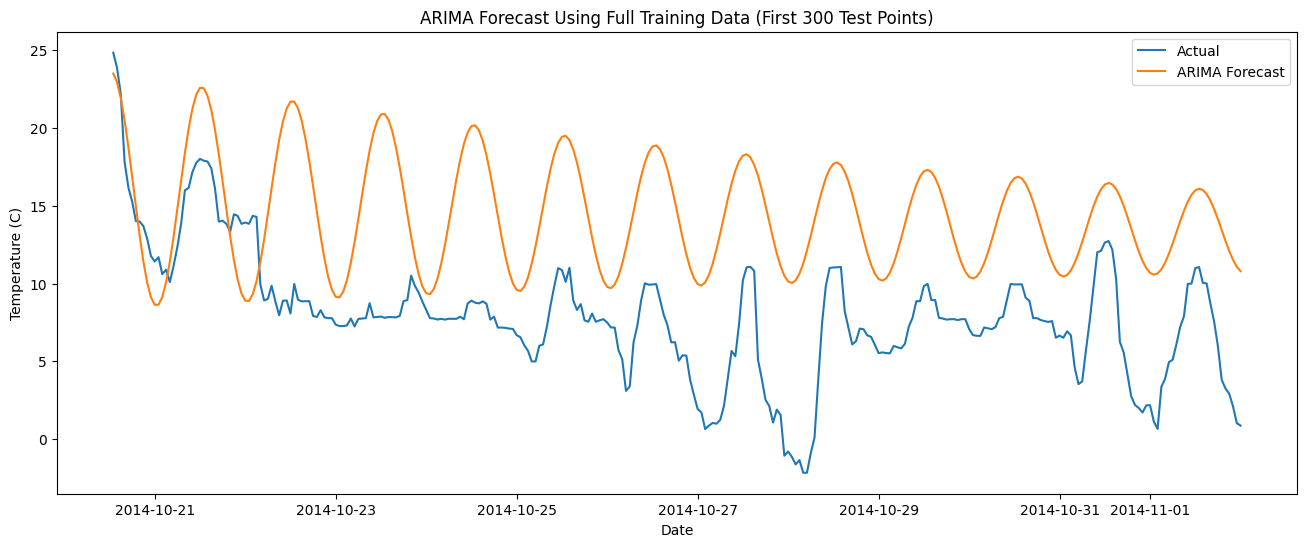

In [ ]:
# First 300 test points
y_test_300 = y_test.iloc[:300]

pred_arima_full_300 = pred_arima_full.iloc[:300]

plt.figure(figsize=(16,6))

plt.plot(
    y_test_300.index,
    y_test_300.values,
    label="Actual"
)

plt.plot(
    y_test_300.index,
    pred_arima_full_300.values,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast Using Full Training Data (First 300 Test Points)")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.legend()

plt.show()

#### Standard ARIMA Forecast

- The ARIMA forecast was able to capture some short-term oscillatory behavior in the temperature series; however, the predicted patterns remained overly smooth and did not accurately follow the true fluctuations observed in the actual data.

- Although the model generated cyclical forecast waves during the initial forecast horizon, these oscillations gradually decreased over time and converged toward the mean level of the series. This occurs because ARIMA uses previous observations and past errors to model temporal dependencies, allowing it to indirectly reproduce some repeating cyclical behavior present in the training data.

- However, the model does not explicitly include seasonal parameters or seasonal differencing. As a result, ARIMA could not effectively represent the complex daily and yearly seasonal structure of the weather dataset, demonstrating the limitations of standard ARIMA for highly seasonal hourly temperature forecasting.

### ARIMA with rolling forecast 

In [30]:
# ARIMA order
arima_order = (3,0,3)

# Use recent training observations
history = list(y_train[-300:])

rolling_predictions = []

# Forecast only first 300 test points
test_subset = y_test[:300]

for t in range(len(test_subset)):

    try:

        # Fit ARIMA
        model = ARIMA(
            history,
            order=arima_order
        )

        model_fit = model.fit()

        # Forecast next step
        yhat = model_fit.forecast()[0]

    except:

        # Fallback if ARIMA fails
        yhat = history[-1]

    # Save prediction
    rolling_predictions.append(yhat)

    # Add actual observation
    history.append(test_subset.iloc[t])

    # Keep fixed rolling window
    history = history[-300:]

# Convert predictions to Series
rolling_predictions = pd.Series(
    rolling_predictions,
    index=test_subset.index
)

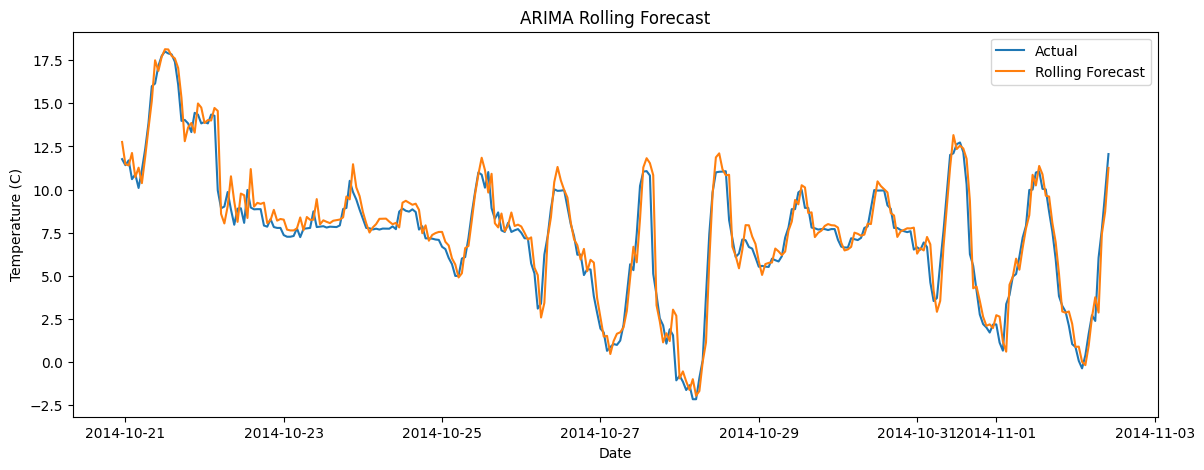


ARIMA Rolling Forecast
RMSE : 0.979
MAE  : 0.692
sMAPE: 15.798
R2   : 0.931


In [31]:
# Plot
plt.figure(figsize=(14,5))

plt.plot(
    test_subset,
    label="Actual"
)

plt.plot(
    rolling_predictions,
    label="Rolling Forecast"
)

plt.legend()

plt.title("ARIMA Rolling Forecast")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.show()

# Evaluation

evaluate(
    "ARIMA Rolling Forecast",
    test_subset.values,
    rolling_predictions.values
)

Demonstrates how updating observations improves a weaker non-seasonal model.

#### ARIMA Rolling Forecast

- The ARIMA rolling forecast shows that the model is able to closely follow the short-term fluctuations in the temperature series. Unlike the standard ARIMA forecast, which tended to converge toward the mean and produce nearly flat predictions, the rolling forecast continuously updates the model using newly observed values. 
- As a result, the predicted values track the actual temperature changes more accurately and capture local variations in the series.

- The forecast was performed on a smaller subset of the testing data due to the high computational cost of rolling forecasting. In a rolling forecast approach, the ARIMA model is repeatedly re-fitted after each new observation, which becomes extremely time-consuming for large hourly datasets. Therefore, a reduced subset of the data was used to demonstrate the rolling forecasting behavior while keeping the computation manageable.

In [77]:
#SARIMA
try:
    # Use last 3 years of training data
    y_train_recent = y_train.iloc[-hours_3_years:]

    model = SARIMAX(
        y_train_recent,
        order=(2,0,2),
        seasonal_order=(1,0,1,24),   # daily seasonality
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=100
    )

    pred_sarima = fitted.forecast(
        steps=len(y_test)
    )

    evaluate(
        "SARIMA (Last 3 Years)",
        y_test.values,
        pred_sarima.values
    )

except Exception as e:
    print("SARIMA Error:", e)


SARIMA (Last 3 Years)
RMSE : 9.339
MAE  : 7.954
sMAPE: 73.39
R2   : -0.058


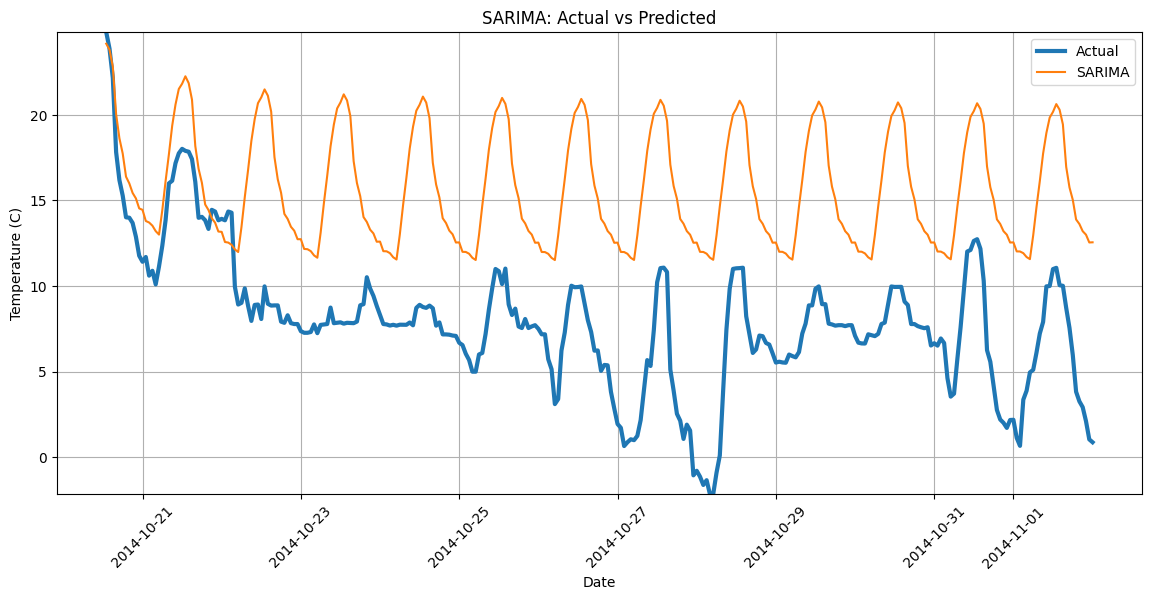

In [ ]:
# SARIMA PLOT
plt.figure(figsize=(14,6))

n = 300

dates = y_test.index[:n]
actual = y_test.values[:n]
sarima_vals = np.array(pred_sarima[:n])

y_min = min(actual.min(), sarima_vals.min())
y_max = max(actual.max(), sarima_vals.max())

plt.plot(dates, actual, label="Actual", linewidth=3)
plt.plot(dates, sarima_vals, label="SARIMA")

plt.ylim(y_min, y_max)

plt.title("SARIMA: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

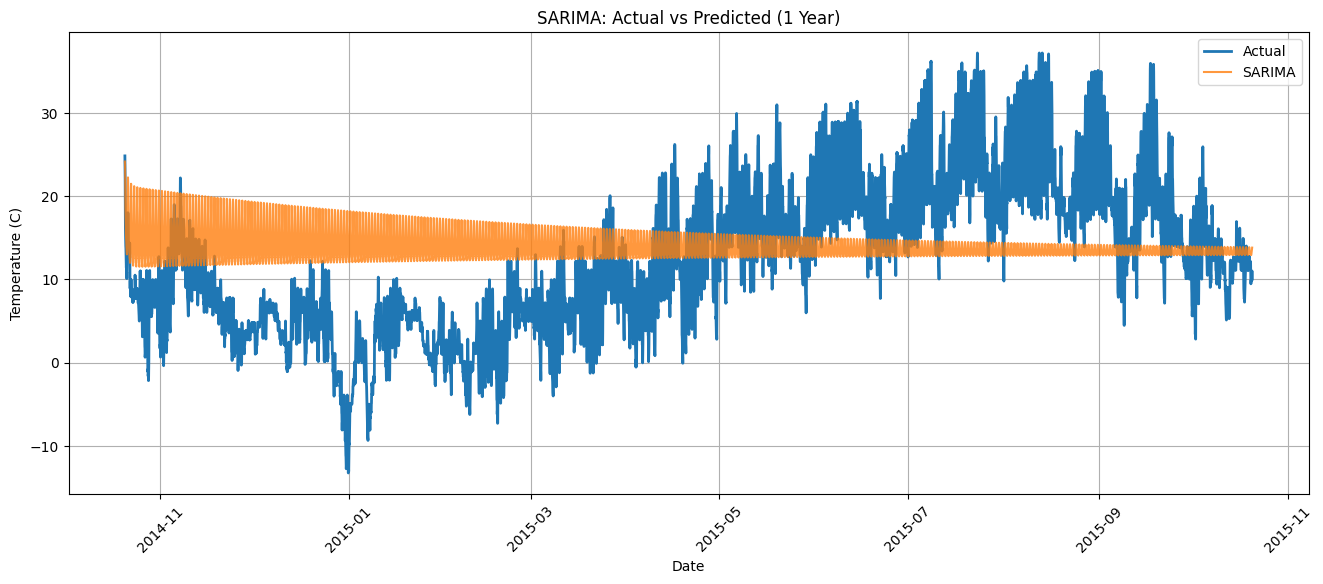

In [ ]:
# SARIMA PLOT (1 YEAR = 24 * 365 = 8760 HOURS)

plt.figure(figsize=(16,6))

n = min(24*365, len(y_test))

dates = y_test.index[:n]
actual = y_test.values[:n]
sarima_vals = np.array(pred_sarima[:n])

plt.plot(dates, actual, label="Actual", linewidth=2)
plt.plot(dates, sarima_vals, label="SARIMA", alpha=0.8)

plt.title("SARIMA: Actual vs Predicted (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### SARIMA Forecast

- The SARIMA model was able to capture the repeating cyclical structure of the temperature series more effectively than the standard ARIMA model. Using the seasonal configuration `(1,0,1,24)`, the model explicitly incorporated a 24-hour seasonal cycle corresponding to daily temperature seasonality in the hourly dataset.

- Unlike standard ARIMA, SARIMA includes seasonal autoregressive and moving average components, allowing the forecast to maintain repeating daily oscillatory patterns throughout the prediction horizon instead of rapidly converging toward a flat mean.

- However, although the model reproduced daily seasonal behavior, the predicted fluctuations remained smoother and more regular than the actual observations. The model struggled to accurately follow abrupt local changes and irregular short-term variations in the temperature series.

- In addition, SARIMA primarily models a single seasonal period at a time. While the dataset contains strong daily and yearly seasonal structures, the selected SARIMA configuration only modeled the daily 24-hour seasonality. This limitation may have reduced the model’s ability to fully capture the more complex multi-seasonal behavior present in the weather data.

In [93]:
#3 EXPONENTIAL SMOOTHING
try:
    model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=24
    ).fit()

    pred_exp = model.forecast(len(y_test))
    evaluate("Exponential Smoothing", y_test, pred_exp)
except:
    pass


Exponential Smoothing
RMSE : 12.267
MAE  : 10.239
sMAPE: 78.739
R2   : -0.825


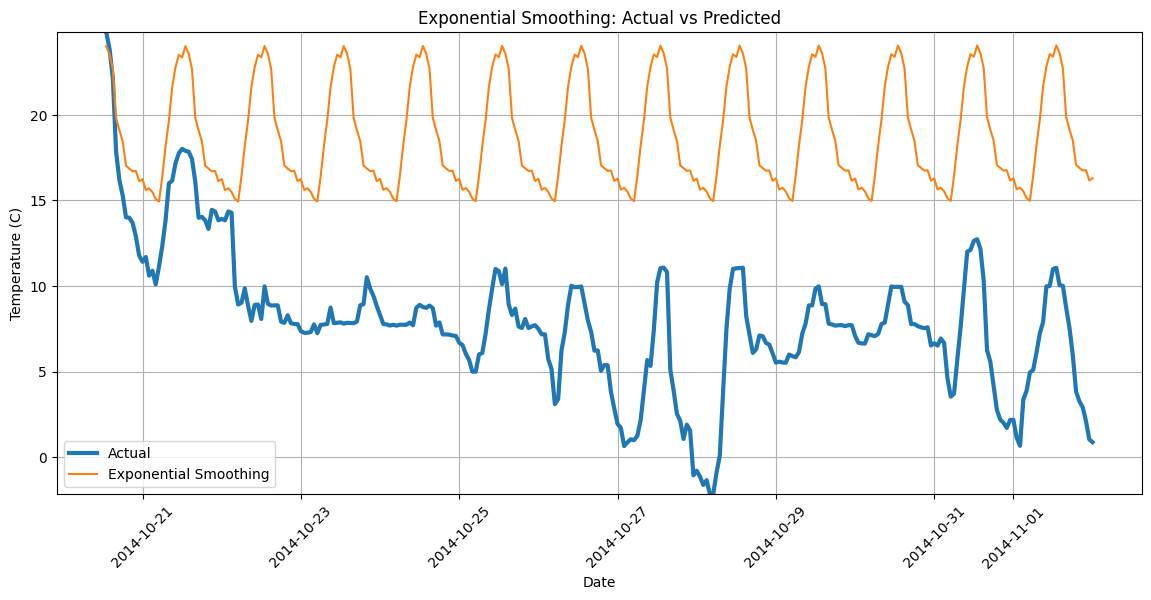

In [ ]:
# EXPONENTIAL SMOOTHING PLOT

plt.figure(figsize=(14,6))

n = 300

dates = y_test.index[:n]
actual = y_test.values[:n]
exp_vals = np.array(pred_exp[:n])

y_min = min(actual.min(), exp_vals.min())
y_max = max(actual.max(), exp_vals.max())

plt.plot(dates, actual, label="Actual", linewidth=3)
plt.plot(dates, exp_vals, label="Exponential Smoothing")

plt.ylim(y_min, y_max)

plt.title("Exponential Smoothing: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

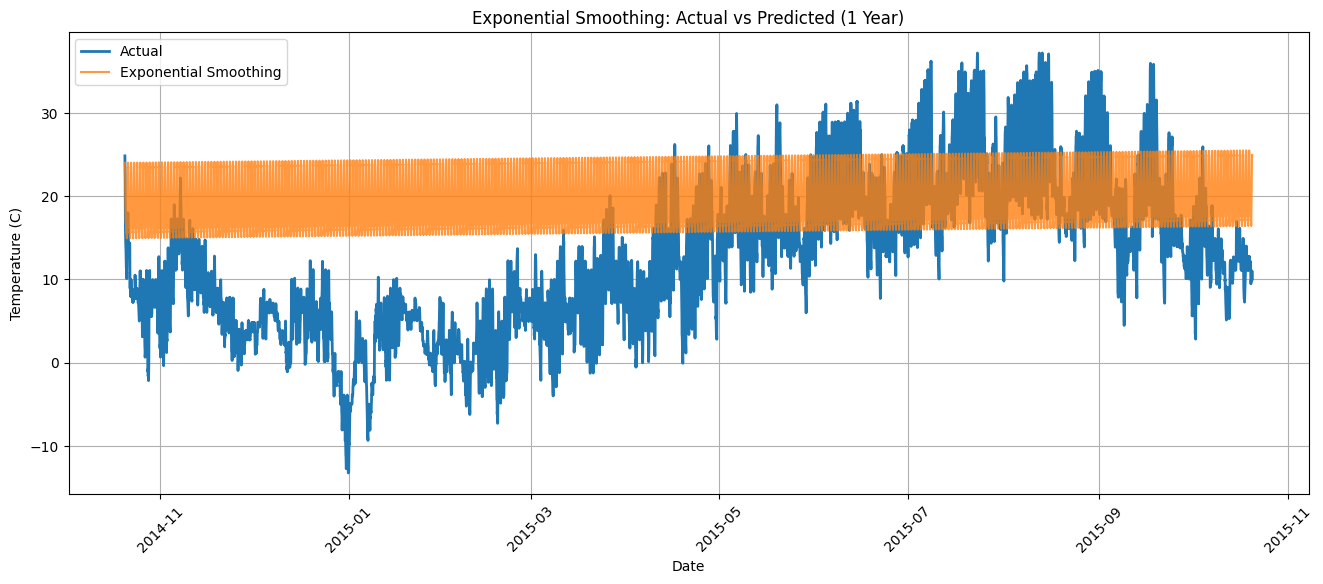

In [ ]:
# EXPONENTIAL SMOOTHING PLOT (1 YEAR)

plt.figure(figsize=(16,6))

n = min(24*365, len(y_test))

dates = y_test.index[:n]
actual = y_test.values[:n]
exp_vals = np.array(pred_exp[:n])

plt.plot(dates, actual, label="Actual", linewidth=2)
plt.plot(dates, exp_vals, label="Exponential Smoothing", alpha=0.8)

plt.title("Exponential Smoothing: Actual vs Predicted (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### Exponential Smoothing Forecast Interpretation 

- The Exponential Smoothing model used additive trend and additive seasonality with a seasonal period of 24 hours, meaning the model learned the repeating daily temperature cycle in the hourly data.

- The forecast was able to maintain clear daily seasonal patterns throughout the entire prediction period. Unlike SARIMA, whose oscillations gradually became flatter over time, Exponential Smoothing kept almost the same repeating seasonal shape and amplitude across the forecast horizon.

- This happens because the model repeats the learned seasonal pattern into the future in a stable and consistent way. However, the predictions were much smoother than the actual temperature values and could not follow sudden fluctuations or irregular changes in the real data.

- Overall, the model captured daily seasonality, but its overall forecasting performance was relatively poor, as shown by the higher error metrics and negative R² score.

### VAR 

In [14]:
# Features for VAR
var_data = df[[
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Pressure (millibars)",
    "Visibility (km)"
]]

# Train-test split
train_size = int(len(var_data) * 0.8)

train_var = var_data.iloc[:train_size]
test_var  = var_data.iloc[train_size:]

In [15]:
#var tuning
from statsmodels.tsa.api import VAR

model = VAR(train_var)

lag_results = model.select_order(15)

print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        16.59       16.59   1.608e+07       16.59
1        7.845       7.848       2552.       7.846
2        7.489       7.496       1789.       7.491
3        7.131       7.141       1250.       7.134
4        7.088       7.100       1197.       7.091
5        7.072       7.088       1179.       7.077
6        7.025       7.043       1124.       7.030
7        7.008       7.030       1106.       7.015
8        6.996       7.020       1092.       7.003
9        6.958       6.986       1052.       6.967
10       6.948       6.978       1041.       6.957
11       6.930       6.964       1023.       6.940
12       6.892       6.929       984.4       6.903
13       6.869       6.908       961.5       6.881
14       6.850       6.893       943.9       6.863
15      6.834*      6.880*      929.1*      6.848*
-------------------------------

In [ ]:
# 4 VAR (Tuned Version)

try:
    vars_cols = [
        "Temperature (C)",
        "Humidity",
        "Wind Speed (km/h)",
        "Pressure (millibars)"
    ]

    var_train = train_var[vars_cols]
    var_test = test_var[vars_cols]

    # Use tuned lag = 15
    model = VAR(var_train).fit(15)

    pred_var = model.forecast(
        var_train.values[-15:],
        steps=len(var_test)
    )

    pred_var = pd.DataFrame(
        pred_var,
        columns=vars_cols
    )

    evaluate(
        "VAR(15)",
        var_test["Temperature (C)"],
        pred_var["Temperature (C)"]
    )

except Exception as e:
    print("VAR Error:", e)


VAR(15)
RMSE : 9.107
MAE  : 7.648
sMAPE: 72.939
R2   : -0.006


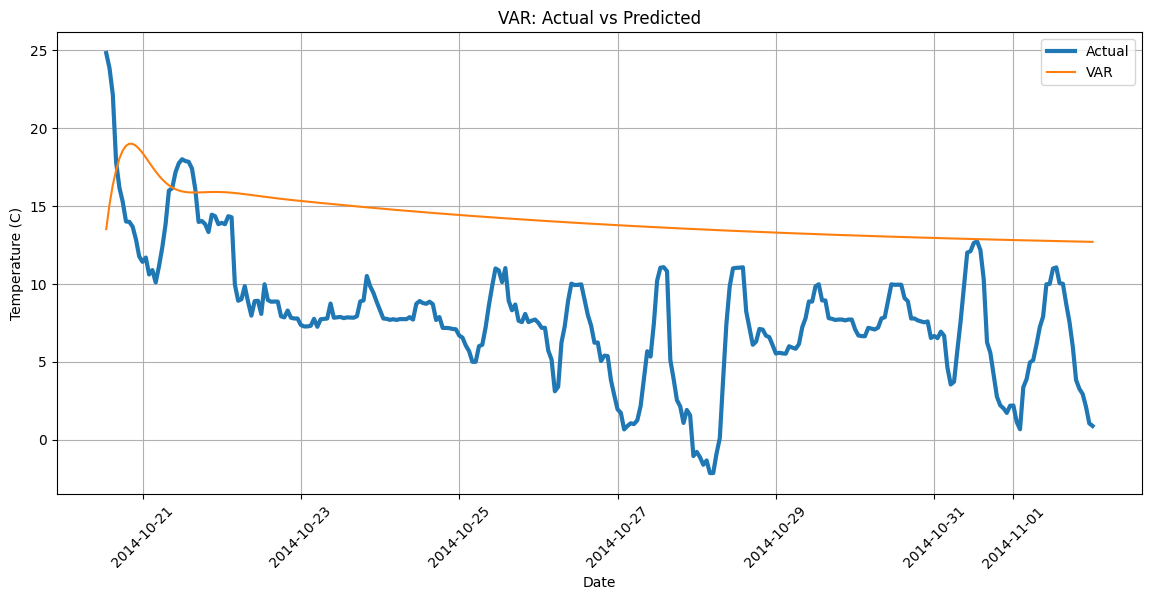

In [32]:
##VAR plot
plt.figure(figsize=(14,6))

n = 300

dates = y_test.index[:n]

actual = y_test.values[:n]

var_vals = pred_var["Temperature (C)"].values[:n]

plt.plot(dates, actual, label="Actual", linewidth=3)
plt.plot(dates, var_vals, label="VAR")

plt.title("VAR: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

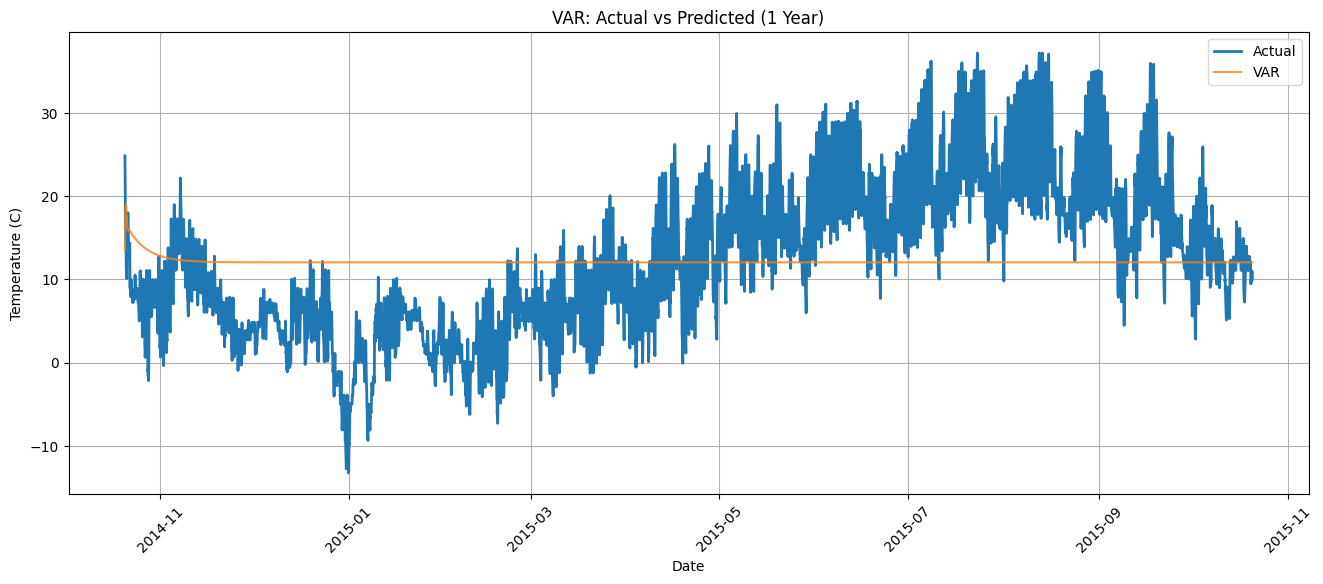

In [29]:
# VAR PLOT (1 YEAR)

plt.figure(figsize=(16,6))

n = min(24*365, len(y_test))

dates = y_test.index[:n]
actual = y_test.values[:n]
var_vals = pred_var["Temperature (C)"].values[:n]

plt.plot(dates, actual, label="Actual", linewidth=2)
plt.plot(dates, var_vals, label="VAR", alpha=0.8)

plt.title("VAR: Actual vs Predicted (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### VAR Forecast Interpretation

- The Vector Autoregression (VAR) model was built using multiple weather-related variables, including temperature, humidity, wind speed, and pressure. Unlike univariate models such as ARIMA and SARIMA, VAR models the relationships between several variables simultaneously and uses past values of all variables to predict future observations.

- Lag order selection was performed using multiple information criteria (AIC, BIC, FPE, and HQIC). The optimal lag suggested by the selection process was 15, meaning the model considered information from the previous 15 hourly observations when generating forecasts.

- The forecast results show that the VAR model mainly captured the overall average level of the temperature series but struggled to reproduce the strong seasonal and cyclical fluctuations present in the actual data. The predictions gradually became smoother and converged toward a relatively stable mean level over longer forecasting horizons.

- Although the model incorporated several correlated weather variables, it still had difficulty modeling the complex multi-seasonal structure and irregular short-term variability of the temperature series.

- Overall, the VAR model achieved slightly better performance than some of the previous statistical models based on the evaluation metrics, but it was still unable to accurately capture the highly dynamic and seasonal behavior of the real temperature data.

## Machine Learning models 
### 1.  Random Forest 
### 2. Gradient Boosting
### 3. SVR

### 1.  Random Forest 

In [35]:
#tuning for rndm forest

params = {
    "n_estimators":[100,200],
    "max_depth":[5,10]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=3,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [36]:
# 5 RANDOM FOREST (TUNED)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rnd = rf.predict(X_test)

evaluate(
    "Random Forest Tuned",
    y_test,
    pred_rnd
)


Random Forest Tuned
RMSE : 0.826
MAE  : 0.609
sMAPE: 13.563
R2   : 0.992


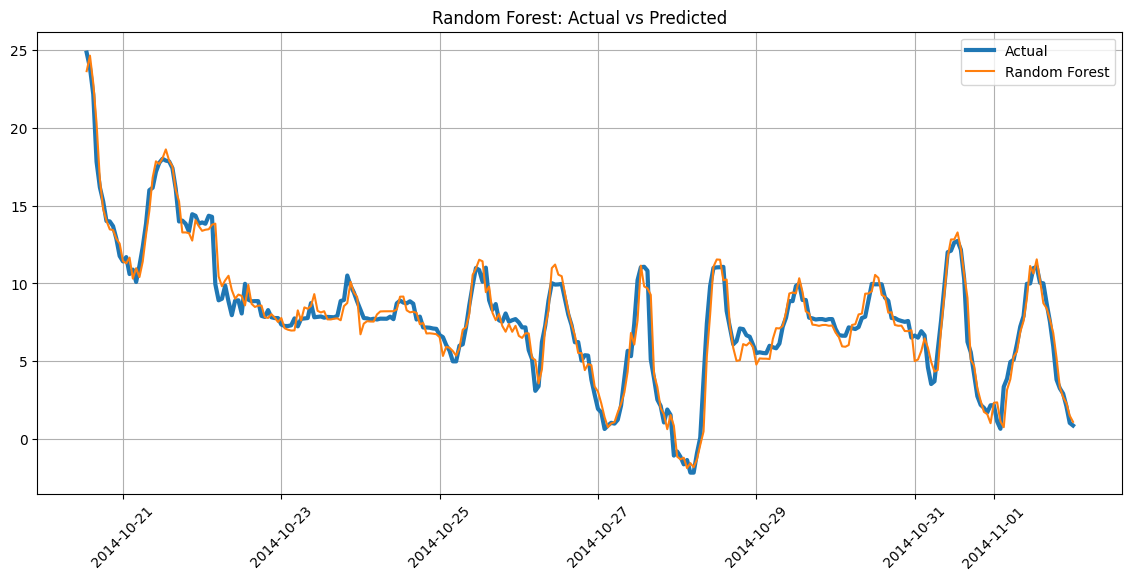

In [38]:
plt.figure(figsize=(14,6))

n = 300

dates = y_test.index[:n]
actual = y_test.values[:n]

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=3
)

plt.plot(
    dates,
    pred_rnd[:n],
    label="Random Forest"
)

plt.title("Random Forest: Actual vs Predicted")

plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.show()

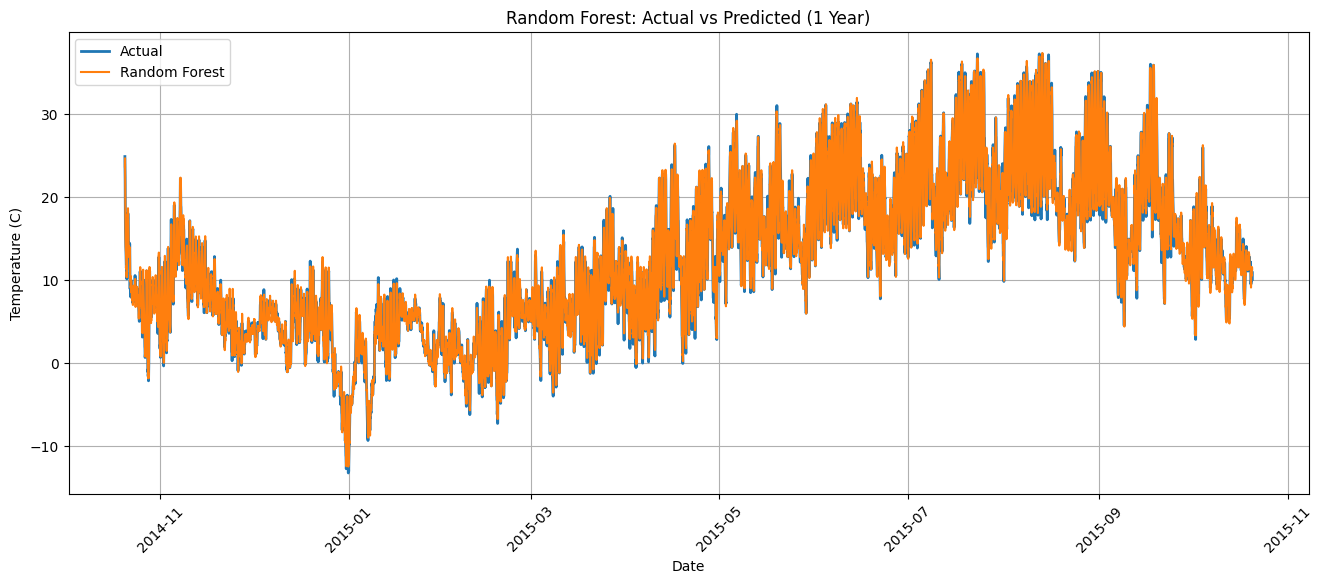

In [ ]:
# RANDOM FOREST LARGER TIME RANGE PLOT

plt.figure(figsize=(16,6))

# 1 year of hourly observations
n_large = 24 * 365

dates_large = y_test.index[:n_large]

actual_large = y_test.values[:n_large]

pred_large = pred_rnd[:n_large]

# Actual values
plt.plot(
    dates_large,
    actual_large,
    label="Actual",
    linewidth=2
)

# Predictions
plt.plot(
    dates_large,
    pred_large,
    label="Random Forest"
)

plt.title("Random Forest: Actual vs Predicted (1 Year)")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### Random Forest Forecast

- The Random Forest model was trained using multiple input features, including weather-related variables and engineered lag features such as previous temperature values and rolling averages. These lag-based features allowed the model to learn temporal dependencies and repeating patterns in the time series data.

- Hyperparameter tuning was performed using GridSearchCV, where different values for the number of trees (`n_estimators`) and tree depth (`max_depth`) were tested using cross-validation. The best configuration was found to be `n_estimators=100` and `max_depth=10`.

- Unlike the statistical models, the Random Forest model was able to closely follow the actual temperature fluctuations and capture both short-term variations and seasonal behavior more accurately. The predicted values aligned very closely with the real observations throughout the forecasting period.

- The model achieved very strong evaluation results, with extremely low RMSE and MAE values, a relatively low sMAPE value, and an R² score close to 1. This indicates that the model explained most of the variability in the temperature series and significantly outperformed the previous statistical forecasting models.

- Overall, the Random Forest model demonstrated excellent forecasting performance and showed that machine learning approaches combined with engineered lag features can effectively model complex and seasonal weather time series data.

### Gradient Boosting

In [40]:
params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    cv=2,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
# GRADIENT BOOSTING FINAL FIT + EVALUATION
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

evaluate(
    "Gradient Boosting Tuned",
    y_test,
    pred_gbr
)


Gradient Boosting Tuned
RMSE : 0.77
MAE  : 0.58
sMAPE: 13.47
R2   : 0.993


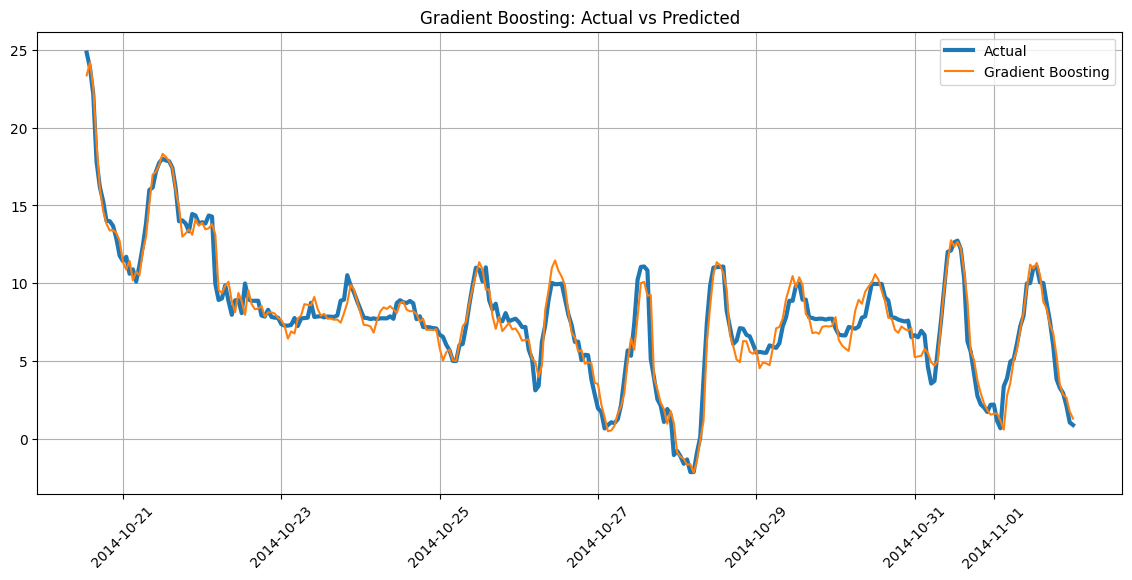

In [43]:
plt.figure(figsize=(14,6))

n = 300

dates = y_test.index[:n]
actual = y_test.values[:n]

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=3
)

plt.plot(
    dates,
    pred_gbr[:n],
    label="Gradient Boosting"
)

plt.title("Gradient Boosting: Actual vs Predicted")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

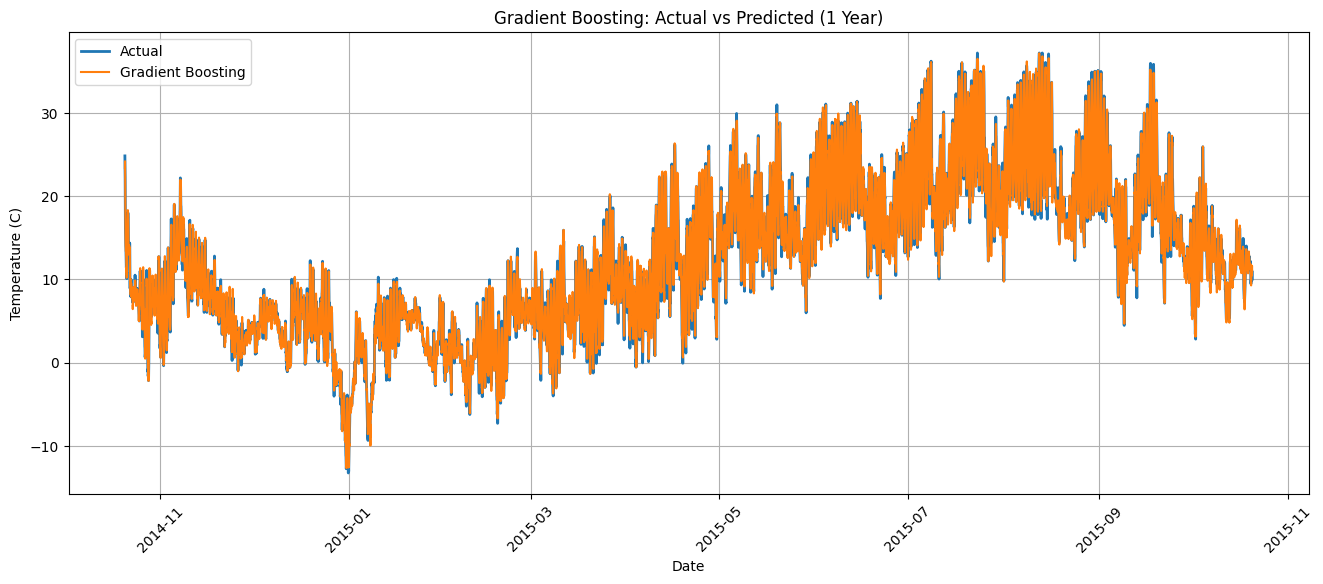

In [44]:
# GRADIENT BOOSTING 1 YEAR PLOT

plt.figure(figsize=(16,6))

# 1 year of hourly observations
n_large = 24 * 365

dates_large = y_test.index[:n_large]

actual_large = y_test.values[:n_large]

gbr_large = pred_gbr[:n_large]

# Actual values
plt.plot(
    dates_large,
    actual_large,
    label="Actual",
    linewidth=2
)

# Predictions
plt.plot(
    dates_large,
    gbr_large,
    label="Gradient Boosting"
)

plt.title("Gradient Boosting: Actual vs Predicted (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.legend()

plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### Gradient Boosting Forecast

- The Gradient Boosting model was trained using multiple weather-related variables together with engineered lag features and rolling statistics. These lag-based features allowed the model to learn temporal dependencies, short-term fluctuations, and repeating seasonal behavior in the temperature series.

- Hyperparameter tuning was performed using GridSearchCV, where different combinations of the number of estimators, learning rate, and tree depth were tested. The best-performing configuration was found to be:
  - `n_estimators = 200`
  - `learning_rate = 0.1`
  - `max_depth = 5`

- The forecast results show that the Gradient Boosting model closely followed the actual temperature values over both short and long forecasting horizons. The model was able to capture seasonal cycles, local fluctuations, and sudden temperature changes much more accurately than the statistical forecasting models.

- Unlike ARIMA, SARIMA, VAR, and Exponential Smoothing, the predictions did not converge toward a flat mean or produce overly smooth repetitive cycles. Instead, the model adapted well to the complex and irregular behavior of the weather data.

- The evaluation metrics also demonstrate very strong forecasting performance. The model achieved very low RMSE and MAE values, a relatively low sMAPE value, and an R² score close to 1, indicating that the forecasts explained almost all variability in the temperature series.

- Overall, the Gradient Boosting model produced one of the best forecasting performances in the project and demonstrated that ensemble machine learning methods combined with lag-based feature engineering can effectively model highly seasonal and nonlinear weather time series data.

#### 3. SVR

In [ ]:
# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
).ravel()

params = {
    "C": [1, 10],
    "gamma": ["scale", 0.1],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVR(),
    params,
    cv=2,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_scaled)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# SVR - FINAL FIT + EVALUATION

svr = SVR(
    C=1,
    gamma="scale",
    kernel="rbf"
)

svr.fit(X_train_scaled, y_train_scaled)

pred_scaled = svr.predict(X_test_scaled)

pred_svr = scaler_y.inverse_transform(
    pred_scaled.reshape(-1,1)
).ravel()

evaluate(
    "SVR Tuned",
    y_test,
    pred_svr
)


SVR Tuned
RMSE : 9.509
MAE  : 8.036
sMAPE: 71.94
R2   : -0.096


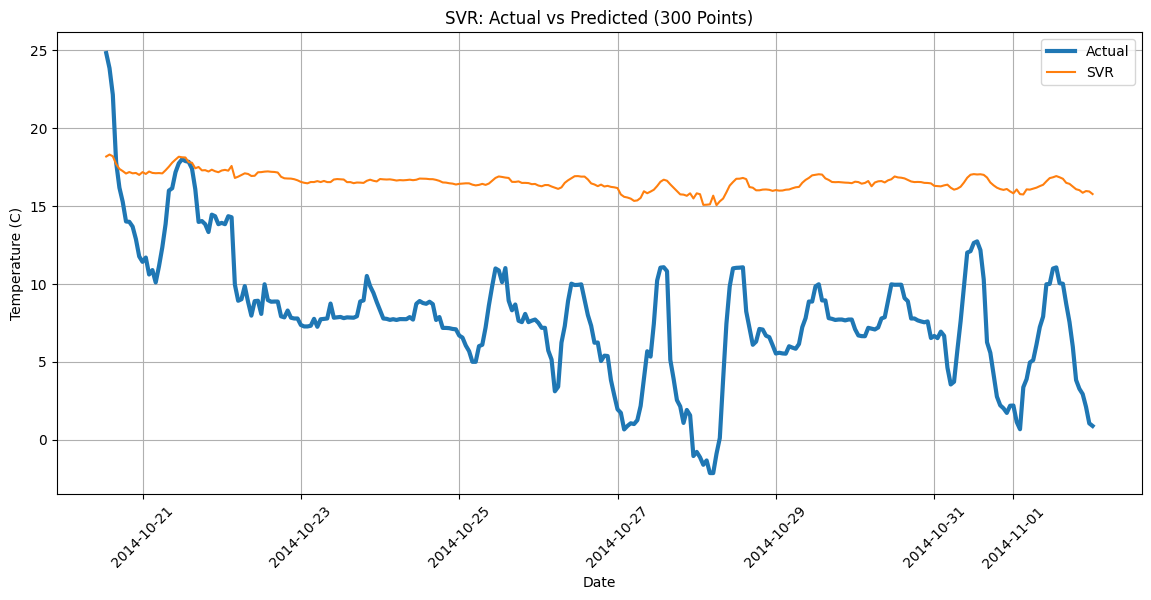

In [ ]:
# SVR PLOT

plt.figure(figsize=(14,6))

n = 300

dates = y_test.index[:n]
actual = y_test.values[:n]
svr_vals = np.array(pred_svr[:n])

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=3
)

plt.plot(
    dates,
    svr_vals,
    label="SVR"
)

plt.title("SVR: Actual vs Predicted (300 Points)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

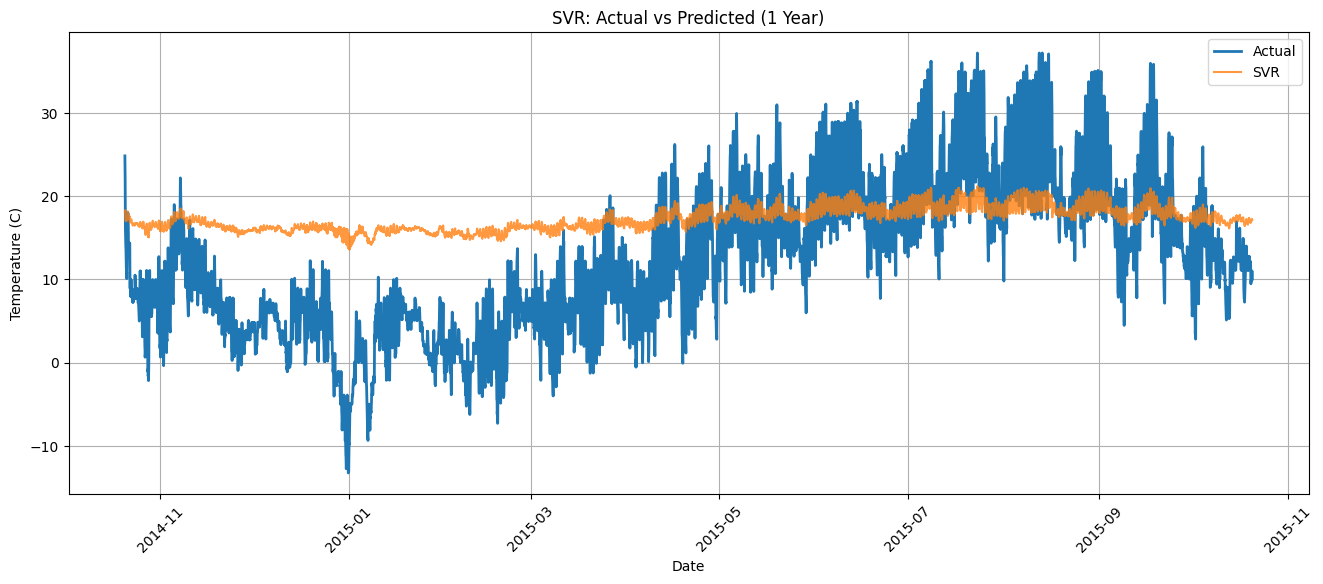

In [ ]:
# SVR PLOT (1 YEAR)
plt.figure(figsize=(16,6))

n = min(24*365, len(y_test))

dates = y_test.index[:n]
actual = y_test.values[:n]
svr_vals = np.array(pred_svr[:n])

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates,
    svr_vals,
    label="SVR",
    alpha=0.8
)

plt.title("SVR: Actual vs Predicted (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# DEEP LEARNING PREP

series = df["Temperature (C)"].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(series)

SEQ = 24

X_seq = []
y_seq = []

for i in range(SEQ, len(scaled)):
    X_seq.append(scaled[i-SEQ:i])
    y_seq.append(scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split2 = int(len(X_seq)*0.8)

Xtr = X_seq[:split2]
Xte = X_seq[split2:]

ytr = y_seq[:split2]
yte = y_seq[split2:]

#### Support Vector Regression (SVR) Forecast

- The Support Vector Regression (SVR) model was trained using multiple weather-related variables together with engineered lag features and rolling statistics. These lag-based features allowed the model to incorporate temporal dependencies and seasonal information from previous observations.

- Before training, the input features and target values were standardized using `StandardScaler`. Scaling was necessary because SVR is highly sensitive to feature magnitudes, and proper normalization helps the optimization process perform more effectively.

- Hyperparameter tuning was performed using GridSearchCV, where different values for the regularization parameter `C`, kernel settings, and gamma values were tested. The best-performing configuration used an RBF (Radial Basis Function) kernel with:
  - `C = 1`
  - `gamma = "scale"`

- The forecast results show that the SVR model captured the general average level and long-term structure of the temperature series, but it struggled to accurately follow the strong fluctuations and seasonal variability present in the actual observations.

- Compared to Random Forest and Gradient Boosting, the SVR predictions were considerably smoother and less responsive to sudden local changes. The model tended to produce stable average-like forecasts rather than closely tracking the dynamic behavior of the real temperature data.

- The evaluation metrics also indicate relatively weak forecasting performance, with high RMSE and MAE values, high sMAPE, and a negative R² score. This suggests that the model was unable to explain the variability of the temperature series effectively.

- Overall, although SVR incorporated lag-based temporal features and nonlinear modeling through the RBF kernel, it struggled to model the highly seasonal and complex structure of the weather dataset compared to the ensemble tree-based machine learning models.

## Deep Learning Models
### 1. LSTM
### 2. GRU
### 3. CNN

#### Preprocessing data

In [45]:
# PREPARE DATA FOR LSTM / GRU / CNN
# Scale target only
scaler = MinMaxScaler()

y_train_scaled = scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_test_scaled = scaler.transform(
    y_test.values.reshape(-1,1)
)

# Sequence length
lookback = 24

# Create sequences
def create_sequences(data, steps=24):
    X, y = [], []

    for i in range(len(data) - steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])

    return np.array(X), np.array(y)

X_train_dl, y_train_dl = create_sequences(
    y_train_scaled,
    lookback
)

X_test_dl, y_test_dl = create_sequences(
    y_test_scaled,
    lookback
)

print(X_train_dl.shape, y_train_dl.shape)
print(X_test_dl.shape, y_test_dl.shape)

(77102, 24, 1) (77102, 1)
(19258, 24, 1) (19258, 1)


### LSTM

In [49]:
#LSTM TUNING
best_units = None
best_val = float("inf")

for units in [32, 64]:
    
    model = Sequential()
    model.add(LSTM(units, input_shape=(lookback,1)))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_dl,
        y_train_dl,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0,
        callbacks=[early]
    )

    val = min(history.history["val_loss"])

    print("Units:", units, " Val Loss:", val)

    if val < best_val:
        best_val = val
        best_units = units

print("Best LSTM Units:", best_units)

Units: 32  Val Loss: 0.00023267715005204082
Units: 64  Val Loss: 0.00023885404516477138
Best LSTM Units: 32


In [50]:
# 1 LSTM FINAL FIT + EVALUATION
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(lookback,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

early = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

model.fit(
    X_train_dl,
    y_train_dl,
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[early]
)

pred_lstm = model.predict(X_test_dl)

pred_lstm = scaler.inverse_transform(pred_lstm).ravel()
true = scaler.inverse_transform(y_test_dl).ravel()

evaluate(
    "LSTM Tuned",
    true,
    pred_lstm
)

Epoch 1/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0021
Epoch 2/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 4.3968e-04
Epoch 3/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.8598e-04
Epoch 4/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3.7939e-04
Epoch 5/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3.6373e-04
Epoch 6/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 3.4682e-04
Epoch 7/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.2777e-04
Epoch 8/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3.1858e-04
Epoch 9/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 3.1477e-04
Epoch 10/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.1033e-04
Epoch 11/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.0792e-04
Epoch 12/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.0582e-04
Epoch 13/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.0477e-04
Epoch 14/20
2410/2410 ━━━━━━━━━━━━━━━━

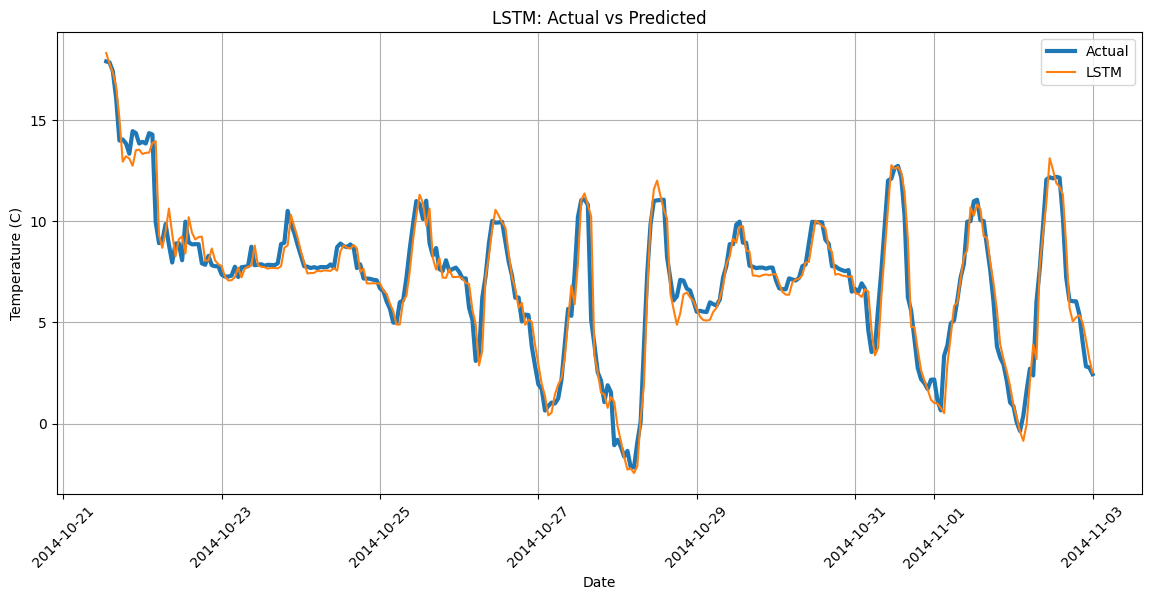

In [51]:
# LSTM PLOT

plt.figure(figsize=(14,6))

# Because sequences remove first lookback rows
dates = y_test.index[lookback:lookback+300]

plt.plot(
    dates,
    true[:300],
    label="Actual",
    linewidth=3
)

plt.plot(
    dates,
    pred_lstm[:300],
    label="LSTM"
)

plt.title("LSTM: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

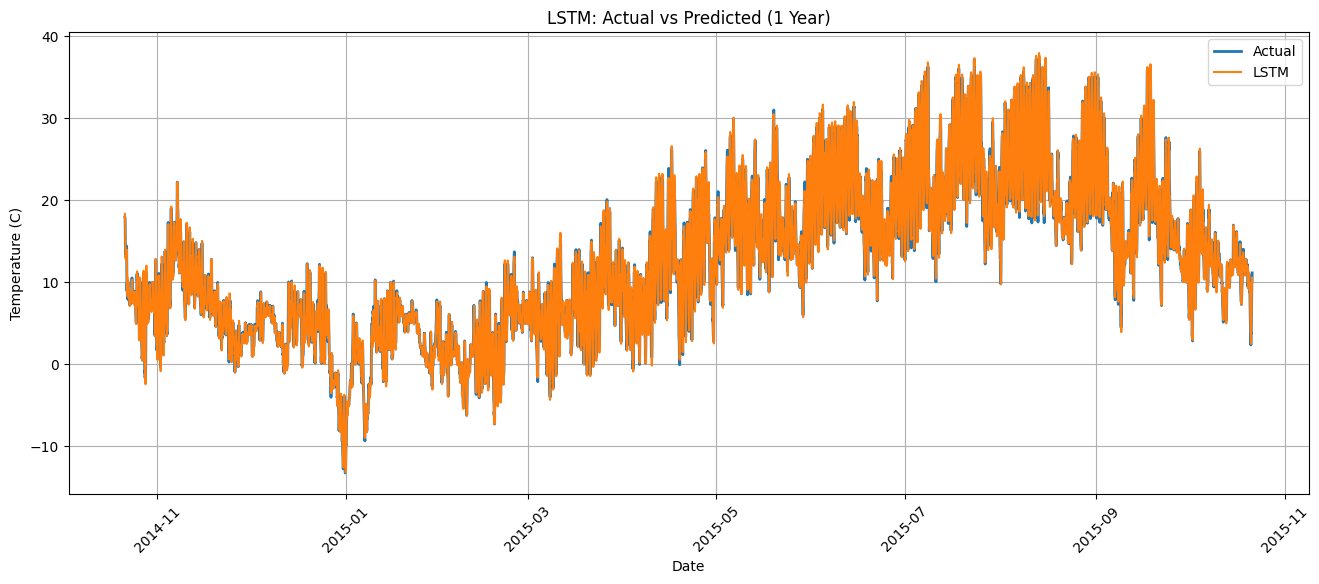

In [ ]:
# LSTM — 1 YEAR PLOT

plt.figure(figsize=(16,6))

# 1 year of hourly observations
n_large = 24 * 365

# Because sequence creation removes first lookback rows
dates_large = y_test.index[
    lookback : lookback + n_large
]

# Actual values
actual_large = scaler.inverse_transform(
    y_test_dl
).ravel()[:n_large]

# Predictions
pred_large = pred_lstm[:n_large]

plt.plot(
    dates_large,
    actual_large,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates_large,
    pred_large,
    label="LSTM"
)

plt.title("LSTM: Actual vs Predicted (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### LSTM Forecast

- The LSTM model was trained using sequential temperature observations with a lookback window of 24 hours, meaning the model predicted future temperatures using the previous 24 hourly values. This allowed the network to learn temporal dependencies and daily seasonal patterns directly from the data.

- Before training, the temperature values were scaled using `MinMaxScaler`, and the data was transformed into sequence-based tensors suitable for deep learning models.

- Hyperparameter tuning was performed by testing different numbers of LSTM units, while early stopping was used to reduce overfitting and restore the best model weights.

- The forecast results show that the LSTM model closely followed the actual temperature series over both short-term and long-term horizons. The model successfully captured seasonal cycles, nonlinear behavior, and rapid temperature changes.

- The evaluation metrics also demonstrate very strong forecasting performance, with low RMSE, MAE, and sMAPE values, together with an R² score close to 1.

- Overall, the LSTM model proved highly effective for forecasting complex seasonal weather time series data.

### GRU

In [53]:
# 2 GRU - TUNING ONLY
best_units = None
best_val = float("inf")

for units in [32, 64]:

    model = Sequential()
    model.add(GRU(units, input_shape=(lookback,1)))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_dl,
        y_train_dl,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0,
        callbacks=[early]
    )

    val = min(history.history["val_loss"])

    print("Units:", units, " Val Loss:", val)

    if val < best_val:
        best_val = val
        best_units = units

print("Best GRU Units:", best_units)

Units: 32  Val Loss: 0.00024005425802897662
Units: 64  Val Loss: 0.00026577519020065665
Best GRU Units: 32


In [54]:
# 2 GRU - FINAL FIT + EVALUATION

model = Sequential()
model.add(GRU(best_units, input_shape=(lookback,1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=32,
    verbose=0
)

pred_gru = model.predict(X_test_dl)

pred_gru = scaler.inverse_transform(pred_gru).ravel()
true = scaler.inverse_transform(y_test_dl).ravel()

evaluate("GRU Tuned", true, pred_gru)

602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

GRU Tuned
RMSE : 0.872
MAE  : 0.63
sMAPE: 14.053
R2   : 0.991


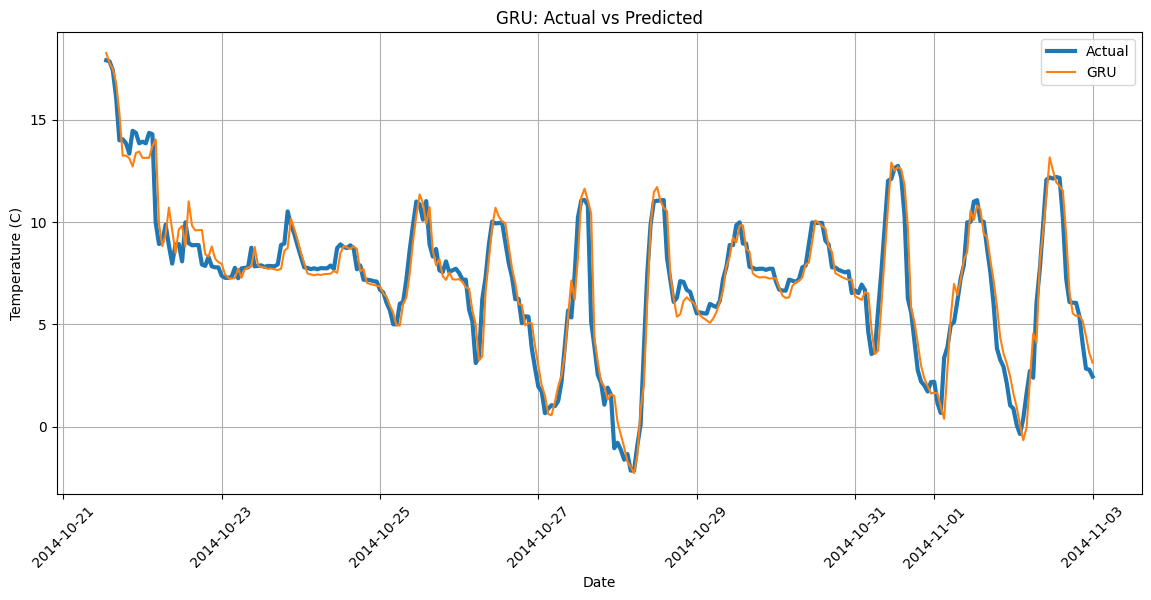

In [55]:
# GRU 300 POINT PLOT

plt.figure(figsize=(14,6))

# Because sequences remove first lookback rows
dates = y_test.index[
    lookback : lookback + 300
]

plt.plot(
    dates,
    true[:300],
    label="Actual",
    linewidth=3
)

plt.plot(
    dates,
    pred_gru[:300],
    label="GRU"
)

plt.title("GRU: Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

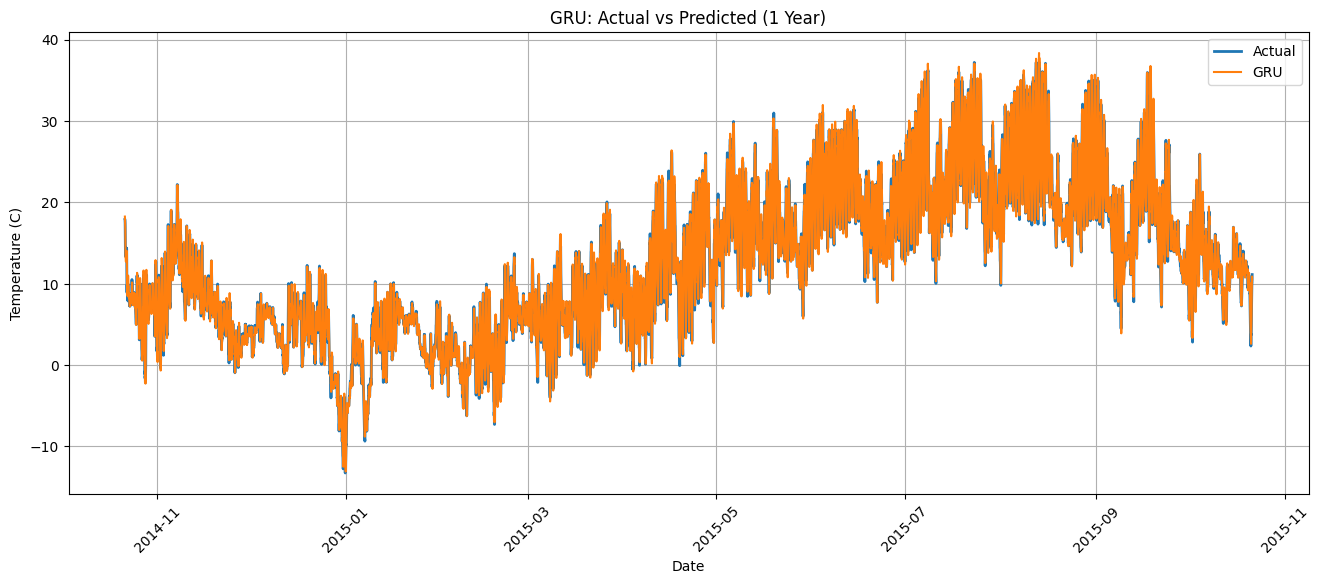

In [ ]:
# GRU 1 YEAR PLOT
plt.figure(figsize=(16,6))

# 1 year of hourly observations
n_large = 24 * 365

# Adjust dates because of sequence generation
dates_large = y_test.index[
    lookback : lookback + n_large
]

actual_large = true[:n_large]

pred_large = pred_gru[:n_large]

# Actual values
plt.plot(
    dates_large,
    actual_large,
    label="Actual",
    linewidth=2
)

# Predictions
plt.plot(
    dates_large,
    pred_large,
    label="GRU"
)

plt.title("GRU: Actual vs Predicted (1 Year)")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

#### GRU Forecast

- The GRU model was trained using sequential temperature observations with a 24-hour lookback window, allowing the network to learn temporal dependencies and daily seasonal patterns directly from previous hourly observations.

- Prior to training, the temperature values were scaled using `MinMaxScaler` to improve training stability and neural network optimization.

- Hyperparameter tuning was performed using different numbers of GRU units, and the best-performing configuration used:
  - `32 GRU units`

- Compared to LSTM, the GRU architecture is simpler and uses fewer internal parameters, which reduces computational complexity while still maintaining strong sequence learning capability.

- The forecast results show that the GRU model closely followed the actual temperature fluctuations over both short-term and long-term forecasting horizons, successfully capturing seasonal cycles and nonlinear behavior in the weather data.

- The evaluation metrics also indicate excellent forecasting performance:
  - `RMSE = 0.872`
  - `MAE = 0.63`
  - `sMAPE = 14.053`
  - `R² = 0.991`

- Overall, the GRU model achieved performance very similar to the LSTM model while using a simpler recurrent neural network structure.

### CNN

In [ ]:
# CNN TUNING ONLY

best_filters = None
best_val = float("inf")

for filters in [32, 64]:

    model = Sequential()

    model.add(
        Conv1D(
            filters=filters,
            kernel_size=3,
            activation="relu",
            input_shape=(lookback,1)
        )
    )

    model.add(Flatten())
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_dl,
        y_train_dl,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0,
        callbacks=[early]
    )

    val = min(history.history["val_loss"])

    print("Filters:", filters, " Val Loss:", val)

    if val < best_val:
        best_val = val
        best_filters = filters

print("Best CNN Filters:", best_filters)

Filters: 32  Val Loss: 0.00022647494915872812
Filters: 64  Val Loss: 0.0002336214092792943
Best CNN Filters: 32


In [58]:
# CNN FINAL FIT + EVALUATION

model = Sequential()

model.add(
    Conv1D(
        filters=best_filters,
        kernel_size=3,
        activation="relu",
        input_shape=(lookback,1)
    )
)

model.add(Flatten())
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=32,
    verbose=0
)

pred_cnn = model.predict(X_test_dl)

pred_cnn = scaler.inverse_transform(pred_cnn).ravel()
true = scaler.inverse_transform(y_test_dl).ravel()

evaluate("CNN Tuned", true, pred_cnn)

602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  

CNN Tuned
RMSE : 0.91
MAE  : 0.679
sMAPE: 14.725
R2   : 0.99


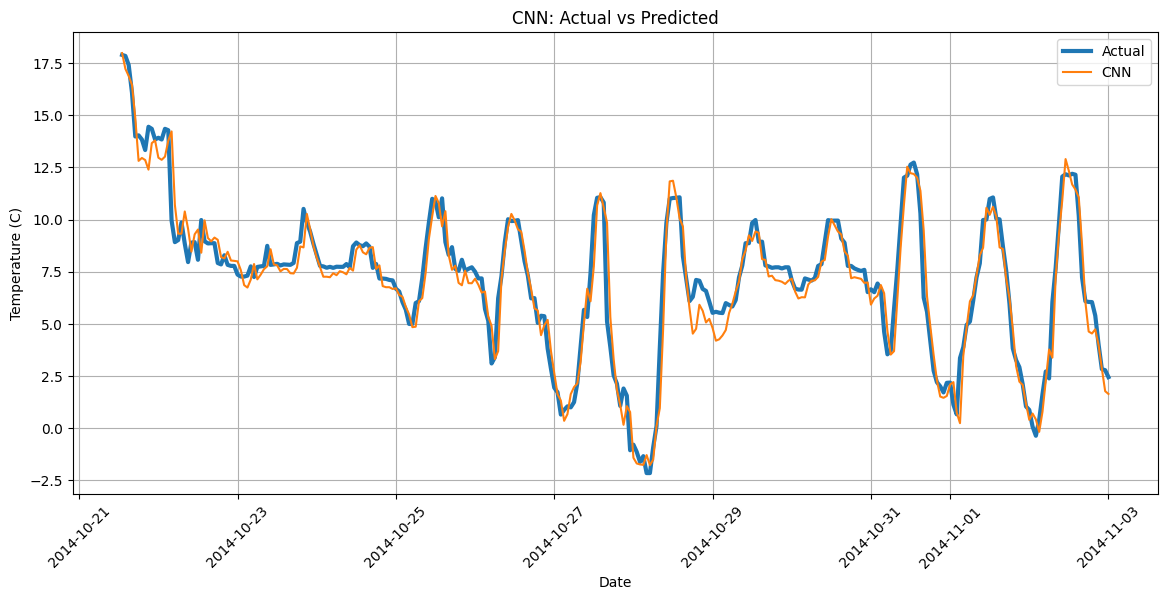

In [59]:
# CNN 300 POINT PLOT

plt.figure(figsize=(14,6))

# Because sequences remove first lookback rows
dates = y_test.index[
    lookback : lookback + 300
]

plt.plot(
    dates,
    true[:300],
    label="Actual",
    linewidth=3
)

plt.plot(
    dates,
    pred_cnn[:300],
    label="CNN"
)

plt.title("CNN: Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

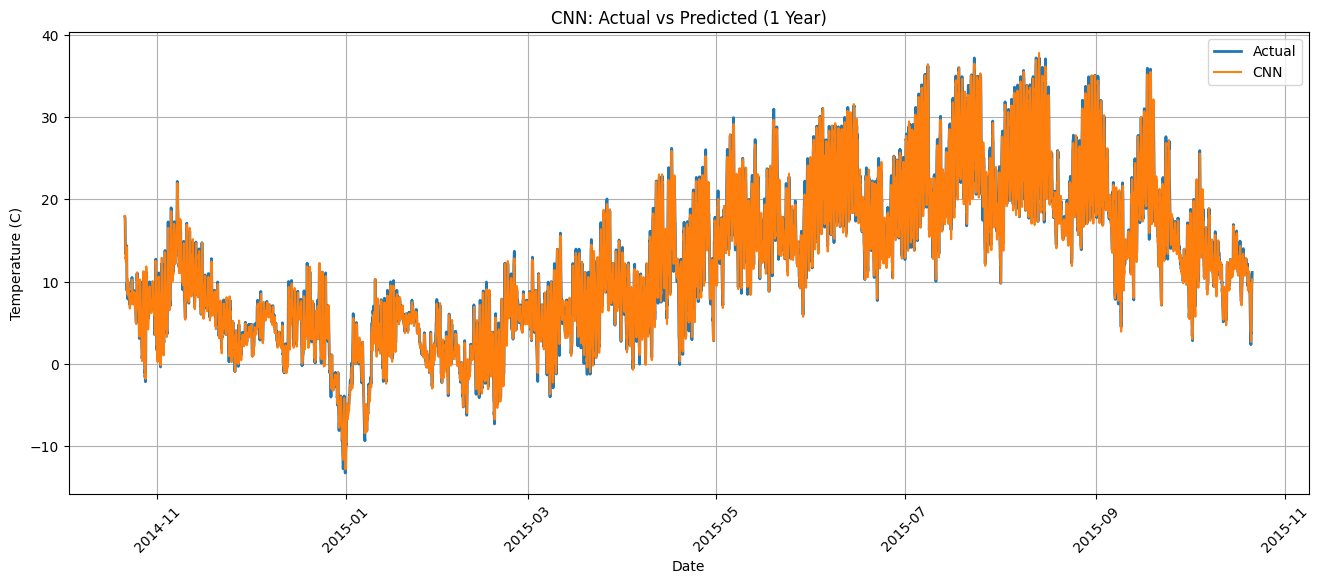

In [ ]:
# CNN 1 YEAR PLOT

plt.figure(figsize=(16,6))

# 1 year of hourly observations
n_large = 24 * 365

# Adjust dates because of sequence generation
dates_large = y_test.index[
    lookback : lookback + n_large
]

actual_large = true[:n_large]

pred_large = pred_cnn[:n_large]

# Actual values
plt.plot(
    dates_large,
    actual_large,
    label="Actual",
    linewidth=2
)

# Predictions
plt.plot(
    dates_large,
    pred_large,
    label="CNN"
)

plt.title("CNN: Actual vs Predicted (1 Year)")

plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### CNN Forecast

- The CNN model was trained using sequential temperature observations with a 24-hour lookback window, allowing the network to learn short-term temporal dependencies and daily seasonal behavior from previous hourly observations.

- Before training, the temperature values were scaled using `MinMaxScaler` to improve training stability and neural network optimization.

- Hyperparameter tuning was performed using different numbers of convolutional filters, and the best-performing configuration used:
  - `32 filters`

- Unlike recurrent models such as LSTM and GRU, the CNN model learns local temporal patterns using convolutional filters. The `Conv1D` layer extracts short-term trends and repeating structures from the sequence data, while the kernel size controls how many neighboring observations are analyzed together.

- The forecast results show that the CNN model closely followed the actual temperature series across both short-term and long-term forecasting horizons. The model successfully captured seasonal cycles, nonlinear fluctuations, and rapid local temperature changes.

- The evaluation metrics also indicate very strong forecasting performance:
  - `RMSE = 0.91`
  - `MAE = 0.679`
  - `sMAPE = 14.725`
  - `R² = 0.99`

- Overall, the CNN model demonstrated strong forecasting capability for highly seasonal weather time series data while using a simpler and computationally efficient deep learning architecture.

## FINAL MODEL COMPARISON GRAPH

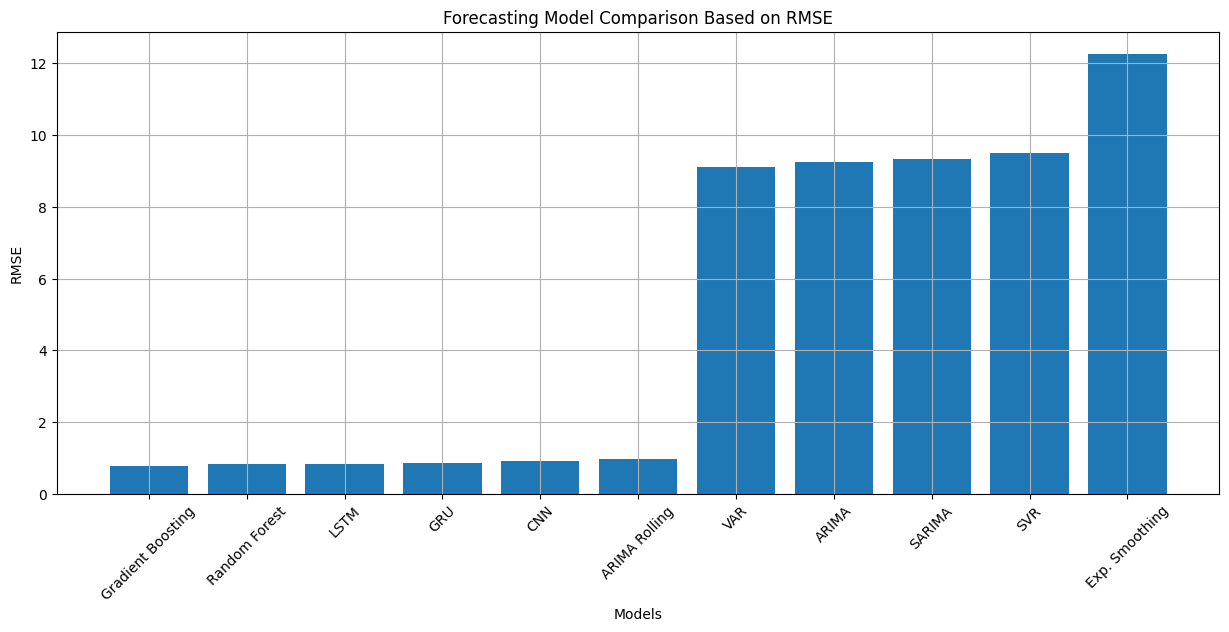

,Model,RMSE,MAE,sMAPE,R2
7,Gradient Boosting,0.770,0.580,13.470,0.993
6,Random Forest,0.826,0.609,13.563,0.992
8,LSTM,0.841,0.600,12.804,0.991
9,GRU,0.872,0.630,14.053,0.991
10,CNN,0.910,0.679,14.725,0.990
1,ARIMA Rolling,0.979,0.692,15.798,0.931
4,VAR,9.107,7.648,72.939,-0.006
0,ARIMA,9.243,7.803,73.834,-0.036
2,SARIMA,9.339,7.954,73.390,-0.058
5,SVR,9.509,8.036,71.940,-0.096


In [ ]:
comparison_results = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "sMAPE", "R2"]
)

# SORT BY RMSE
comparison_results = comparison_results.sort_values("RMSE")

# RMSE COMPARISON PLOT
plt.figure(figsize=(15,6))

plt.bar(
    comparison_results["Model"],
    comparison_results["RMSE"]
)

plt.title("Forecasting Model Comparison Based on RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
comparison_results

## Conclusion

This project explored multiple statistical, machine learning, and deep learning approaches for hourly temperature forecasting using historical weather data.

Traditional statistical models such as ARIMA, SARIMA, Exponential Smoothing, VAR, and SVR struggled to fully capture the seasonal and nonlinear structure of the series. Their forecasts often became overly smooth or converged toward the average temperature level over longer horizons. For example, standard ARIMA produced an RMSE of approximately `9.243`, while Exponential Smoothing showed the weakest overall performance with an RMSE above `12`.

In contrast, machine learning and deep learning models achieved significantly stronger forecasting accuracy. Random Forest and Gradient Boosting successfully modeled nonlinear relationships using engineered lag features and rolling statistics. Among all tested methods, **Gradient Boosting achieved the best overall performance** with:

* `RMSE = 0.770`
* `MAE = 0.580`
* `R² = 0.993`

Deep learning models including LSTM, GRU, and CNN also performed exceptionally well. Using a 24-hour lookback window, these models learned temporal dependencies directly from sequential observations and closely followed real temperature fluctuations across both short-term and long-term forecasts. The LSTM model achieved an RMSE of `0.841`. GRU and CNN obtained similarly strong results.

Overall, the project demonstrated that advanced machine learning and deep learning approaches are substantially more effective than classical statistical methods for highly seasonal and nonlinear weather forecasting tasks.
